In [44]:
setwd('/Users/aricha14/Desktop/Trf_Auxin/')
directory <- "./featureCounts"
list.files(directory)

[1] "N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt"  
[2] "N_C_2_EKRN240043742-1A_22F2GWLT4_L7.counts.txt"  
[3] "N_IAA_2_EKRN240043739-1A_22F2GWLT4_L7.counts.txt"
[4] "N_IAA_3_EKRN240043740-1A_22F2GWLT4_L7.counts.txt"

In [45]:
# Define the paths to the read files 
file_names <- list.files(path=directory, pattern = "*.txt") # create a list of all txt files in the "Tassel_stage1_counts" folder
file_paths <- list.files(path=directory, pattern = "*.txt", full.names=T) # create a list of all txt files' full locations
print(file_names)
print(file_paths)
# Building the counts table 
featureCounts <- read.table(file_paths[1], sep="\t", header=T) # start by reading the first file
#look at the first first file
dim(featureCounts)
head(featureCounts, 10)

[1] "N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt"  
[2] "N_C_2_EKRN240043742-1A_22F2GWLT4_L7.counts.txt"  
[3] "N_IAA_2_EKRN240043739-1A_22F2GWLT4_L7.counts.txt"
[4] "N_IAA_3_EKRN240043740-1A_22F2GWLT4_L7.counts.txt"
[1] "./featureCounts/N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt"  
[2] "./featureCounts/N_C_2_EKRN240043742-1A_22F2GWLT4_L7.counts.txt"  
[3] "./featureCounts/N_IAA_2_EKRN240043739-1A_22F2GWLT4_L7.counts.txt"
[4] "./featureCounts/N_IAA_3_EKRN240043740-1A_22F2GWLT4_L7.counts.txt"


[1] 39756     7

,Geneid,Chr,Start,End,Strand,Length,..Desktop.TRF_AUXIN_RNAseq_July2024.aligned_reads.N_C_1_EKRN240043741.1A_22F2GWLT4_L7.bam
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
1,Zm00001eb000010,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,34617;36037;36259;36600;36822;37416;38021;38571;39701,35318;36174;36504;36713;37004;37633;38482;39618;40204,+;+;+;+;+;+;+;+;+,3615,1308
2,Zm00001eb000020,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,41214;41214;41263;41314;41742;41742;41742;41742;42257;42257;42257;42508;42508;42508;42508;42762;42762;42762;42762;43039;43039;43039;43039;43318;43318;43318;43318;43750;43750;43994;43994;43994;45593;45593;45593,41588;41588;41588;41588;41807;42375;41807;41807;42375;42375;42375;42665;42665;42665;42665;42917;42917;42917;42917;43197;43197;43197;43197;43520;43520;43520;43520;43802;43902;44303;44303;44303;46039;46050;46762,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-,3318,12534
3,Zm00001eb000050,chr1;chr1;chr1;chr1;chr1;chr1;chr1,108554;109172;109340;109498;109706;109882;113762,108564;109264;109411;109622;109790;109951;114382,-;-;-;-;-;-;-,1077,0
4,Zm00001eb000060,chr1;chr1,188559;189146,189088;189581,-;-,966,1318
5,Zm00001eb000070,chr1;chr1;chr1;chr1;chr1;chr1,190192;190301;190624;191350;197313;198535,190199;190561;190681;191442;197368;198832,-;-;-;-;-;-,774,16
6,Zm00001eb000080,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,200262;200916;201124;201433;201662;201912;202483;203022;203302,200810;201043;201211;201571;201838;202158;202592;203229;203393,-;-;-;-;-;-;-;-;-,1738,2939
7,Zm00001eb000100,chr1;chr1;chr1;chr1;chr1;chr1,206619;207090;207447;207679;208377;209221,206995;207244;207582;207819;208969;209723,-;-;-;-;-;-,1905,3
8,Zm00001eb000110,chr1;chr1,246422;246997,246545;247242,-;-,370,0
9,Zm00001eb000120,chr1,315219,315846,+,628,13


In [46]:
featureCounts <- read.table(file_paths[1], sep="\t", header=T) # start by reading the first file
counts <- cbind(featureCounts[,7]) # take the 7th column (counts)
rownames(counts) <- featureCounts[,1] # name by gene

colnames(counts) <- c(file_names[1]) # name the first column

head(counts) # check on the data
dim(featureCounts) # before
dim(counts) # after

for (f in 2:length(file_paths)) { # loop over all the rest of the files
	new_featureCounts <- read.table(file_paths[f],sep="\t", header=T)
	print ("Merging file...")
	counts <- cbind(counts, new_featureCounts[,7]) # add on the new column
	colnames(counts) <- c(file_names[1:f]) # add on the new column's name
}
# View the raw counts table 
head(counts)

,N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt
Zm00001eb000010,1308
Zm00001eb000020,12534
Zm00001eb000050,0
Zm00001eb000060,1318
Zm00001eb000070,16
Zm00001eb000080,2939


[1] 39756     7

[1] 39756     1

[1] "Merging file..."
[1] "Merging file..."
[1] "Merging file..."


,N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt,N_C_2_EKRN240043742-1A_22F2GWLT4_L7.counts.txt,N_IAA_2_EKRN240043739-1A_22F2GWLT4_L7.counts.txt,N_IAA_3_EKRN240043740-1A_22F2GWLT4_L7.counts.txt
Zm00001eb000010,1308,885,1038,959
Zm00001eb000020,12534,10655,11484,9878
Zm00001eb000050,0,0,0,0
Zm00001eb000060,1318,799,825,504
Zm00001eb000070,16,10,7,9
Zm00001eb000080,2939,1353,1404,814


In [47]:
# make the sample table. NOTE: the table order must match the order that the above counts table is in
sampleTable <- read.table (text = "File,Geno,Treatment
N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt,N,Control
N_C_2_EKRN240043742-1A_22F2GWLT4_L7.counts.txt,N,Control
N_IAA_2_EKRN240043739-1A_22F2GWLT4_L7.counts.txt,N,IAA
N_IAA_3_EKRN240043740-1A_22F2GWLT4_L7.counts.txt,N,IAA",  sep=",", header=T)


In [48]:
library(DESeq2)
library(dplyr)
library(ggplot2)

In [49]:
#create dds object using matrix import command
# use straight forward equation for the model as we only have one variable (genotype)
ddsMatrix <- DESeqDataSetFromMatrix(countData=counts, 
                              colData=sampleTable, 
                              design=~Treatment)
ddsMatrix

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


class: DESeqDataSet 
dim: 39756 4 
metadata(1): version
assays(1): counts
rownames(39756): Zm00001eb000010 Zm00001eb000020 ... Zm00001eb443020
  Zm00001eb443030
rowData names(0):
colnames(4): N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt
  N_C_2_EKRN240043742-1A_22F2GWLT4_L7.counts.txt
  N_IAA_2_EKRN240043739-1A_22F2GWLT4_L7.counts.txt
  N_IAA_3_EKRN240043740-1A_22F2GWLT4_L7.counts.txt
colData names(3): File Geno Treatment

In [50]:
#convert into DESeq object -- will estimate dispersion
dds <- DESeq (ddsMatrix)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [51]:
#create variance stabilized table as internal norm
vsd <- varianceStabilizingTransformation(dds)
vsd_filtered <- assay(vsd)

using ntop=1e+05 top features by variance

using ntop=10000 top features by variance



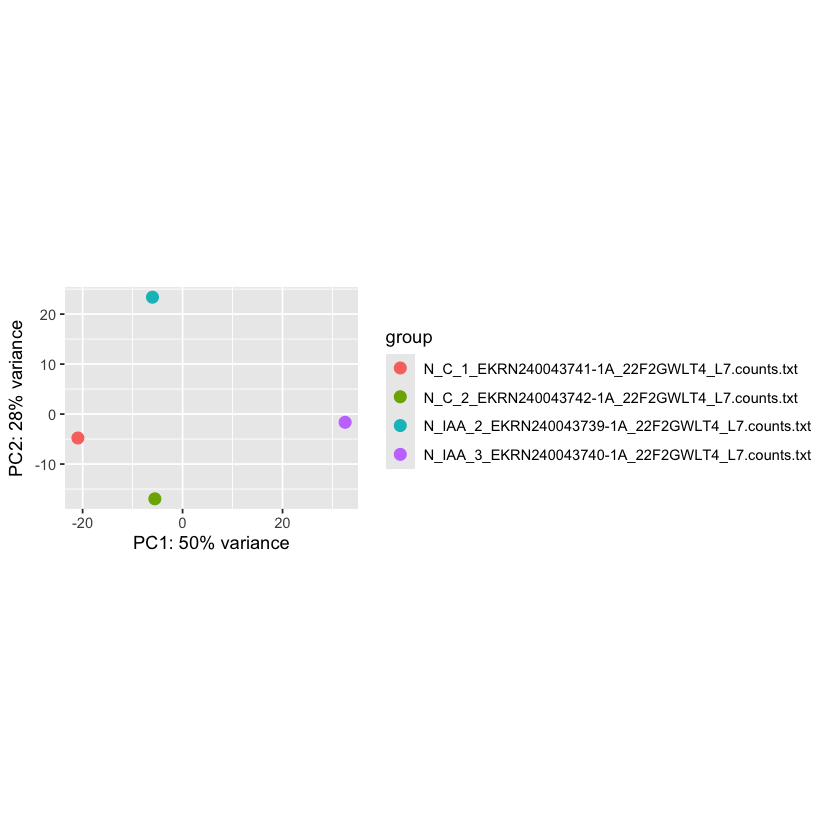

using ntop=1000 top features by variance



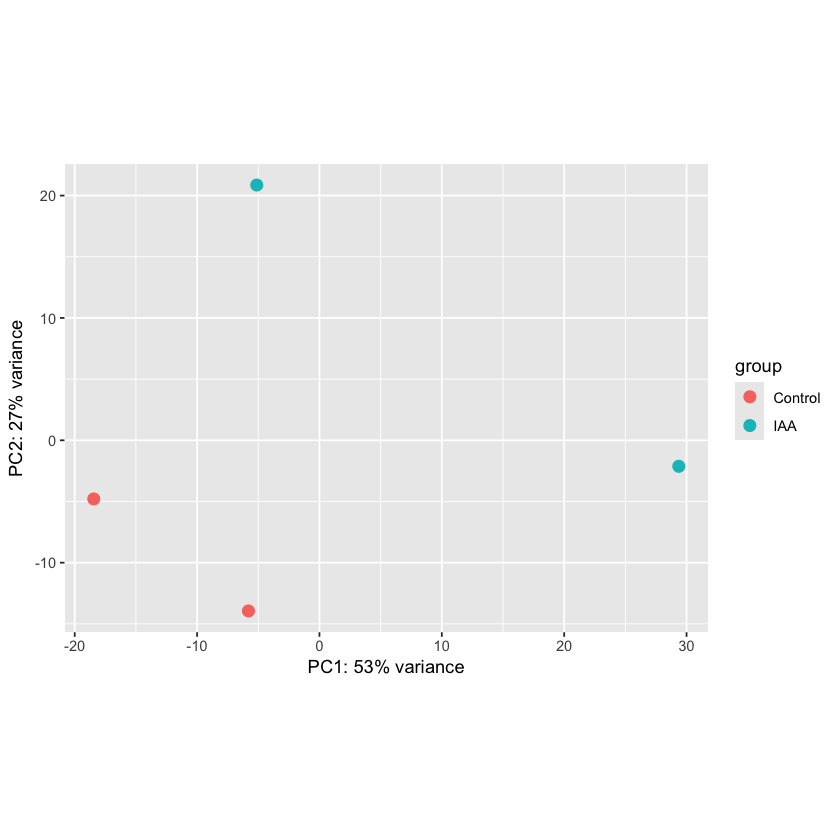

using ntop=100 top features by variance



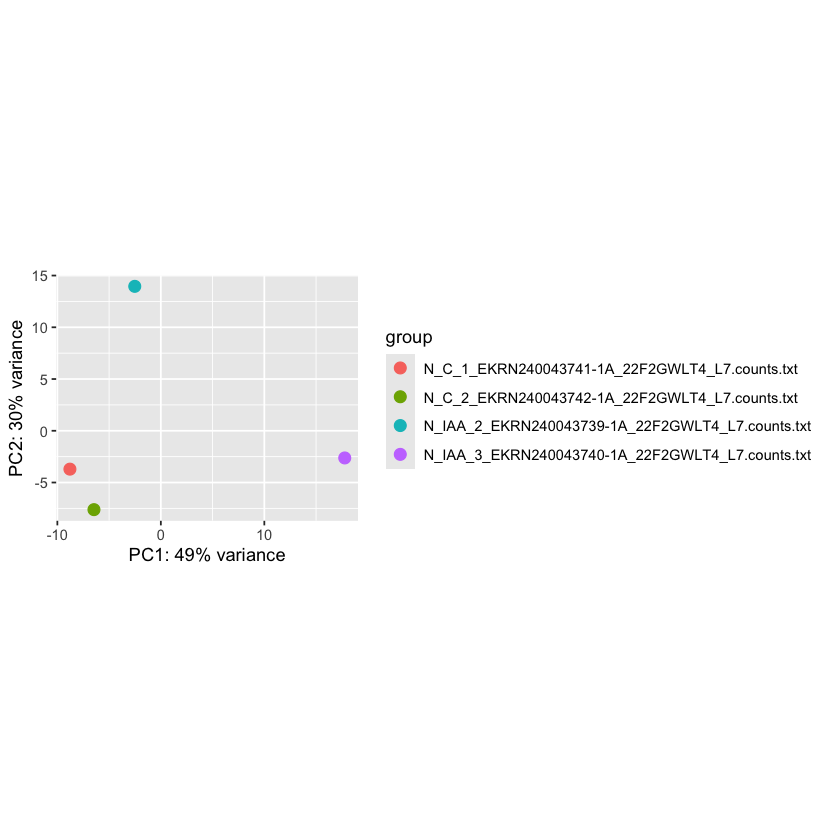

using ntop=10 top features by variance



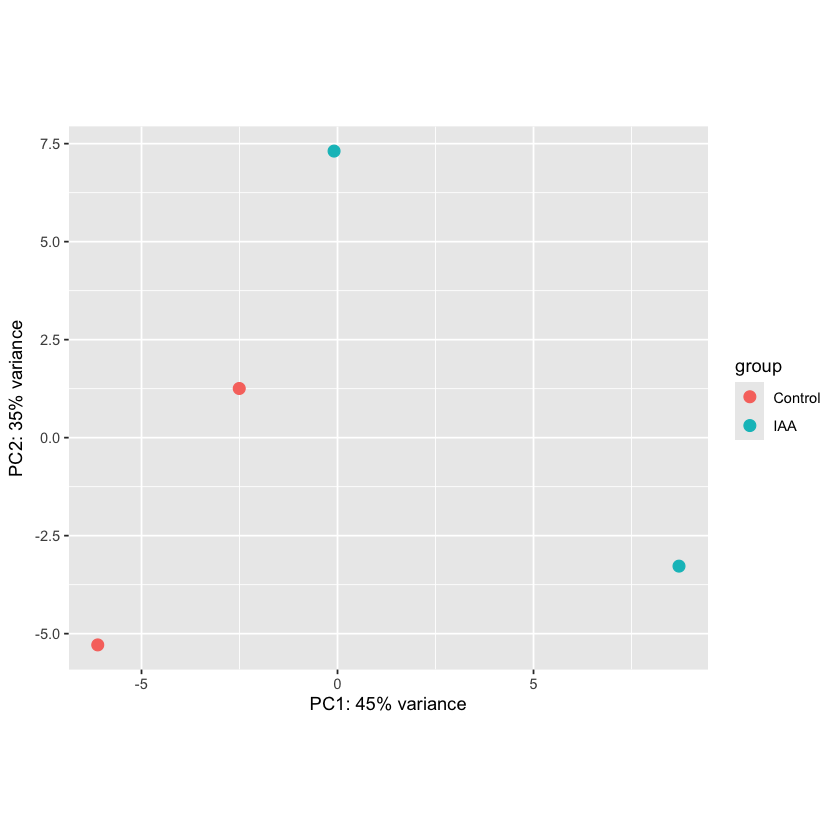

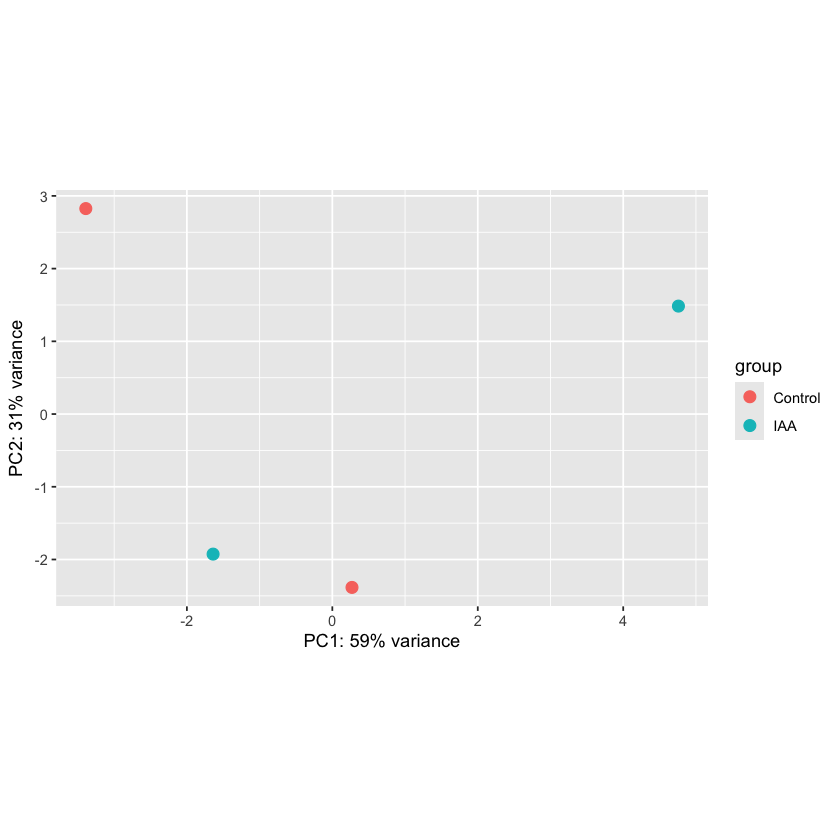

In [52]:
#check PCA plot at a few different levels, colour by genotype
plotPCA(vsd, intgroup=c('File'), ntop=100000)
plotPCA(vsd, intgroup=c('Treatment'), ntop=10000)
plotPCA(vsd, intgroup=c('File'), ntop=1000)
plotPCA(vsd, intgroup=c('Treatment'), ntop=100)
plotPCA(vsd, intgroup=c('Treatment'),ntop=10)
#


out of 30861 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 96, 0.31%
LFC < 0 (down)     : 31, 0.1%
outliers [1]       : 0, 0%
low counts [2]     : 4714, 15%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MLE): Treatment IAA vs Control 
Wald test p-value: Treatment IAA vs Control 
DataFrame with 39756 rows and 6 columns
                  baseMean log2FoldChange     lfcSE      stat    pvalue
                 <numeric>      <numeric> <numeric> <numeric> <numeric>
Zm00001eb000010  1034.3795     -0.0385493  0.202667 -0.190210 0.8491444
Zm00001eb000020 11069.9698     -0.0441615  0.158351 -0.278883 0.7803349
Zm00001eb000050     0.0000             NA        NA        NA        NA
Zm00001eb000060   838.7434     -0.5792955  0.264820 -2.187509 0.0287054
Zm00001eb000070    10.3046     -0.5887194  1.257122 -0.468307 0.6395647
...                    ...            ...       ...       ...       ...
Zm00001eb442990          0             NA        NA        NA        NA
Zm00001eb443000          0             NA        NA        NA        NA
Zm00001eb443010          0             NA        NA        NA        NA
Zm00001eb443020          0             NA        NA        NA        NA
Z

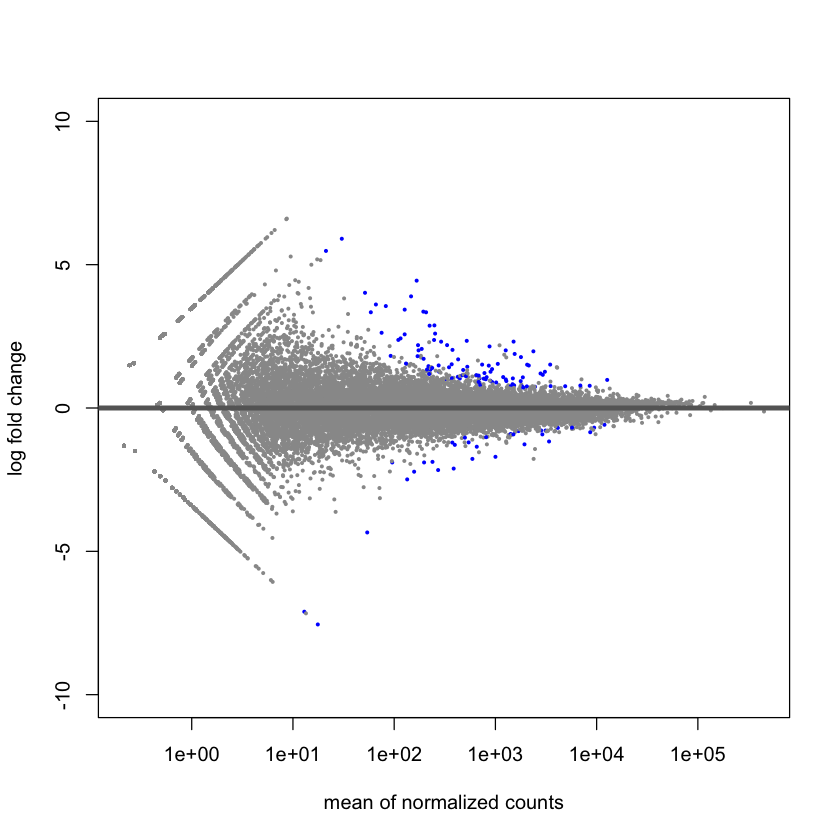

In [53]:
# Compare the mutants to N, and report genes that have padj<0.05. 
# contrast = c("condition", "treated", "nontreated")
# This contrast should report negative log2FC if expression is down in the mutant 
res <- results(dds, contrast=c("Treatment","IAA","Control"), alpha=0.05)
summary(res); #summary
plotMA(res,ylim=c(-10,10)); #smearplot
res

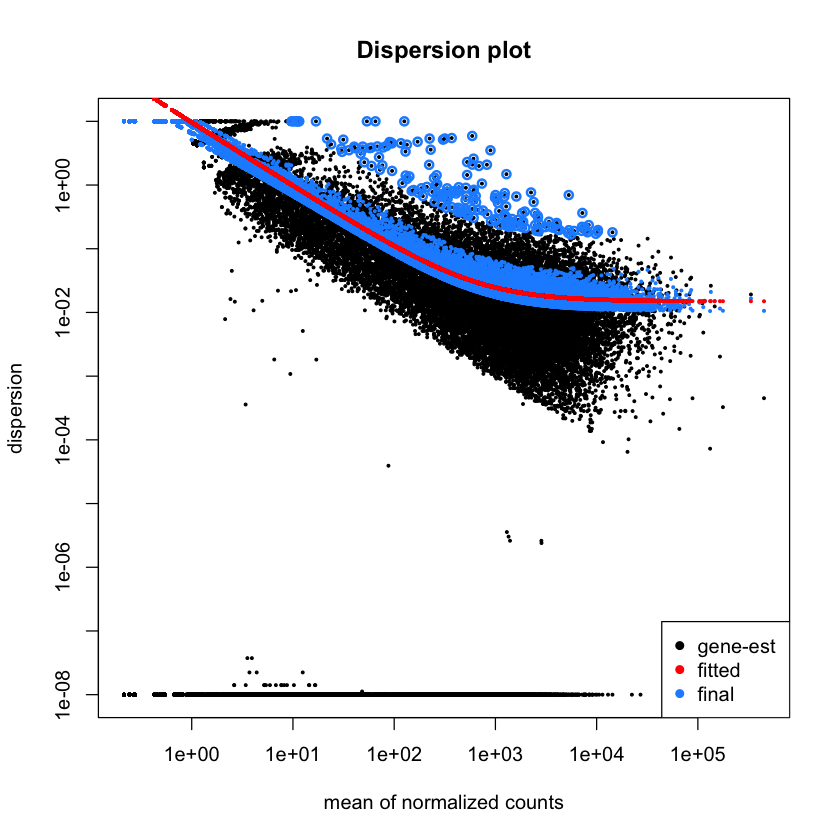

In [54]:
plotDispEsts(dds, main="Dispersion plot")

In [55]:
#filtering
dds <- dds[ rowSums(counts(dds, normalized=TRUE) >= 5) > 2, ] #only consider detected genes, >= 5 RPM in more than 2 replicates



out of 25207 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 95, 0.38%
LFC < 0 (down)     : 30, 0.12%
outliers [1]       : 0, 0%
low counts [2]     : 1955, 7.8%
(mean count < 20)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MLE): Treatment IAA vs Control 
Wald test p-value: Treatment IAA vs Control 
DataFrame with 25207 rows and 6 columns
                  baseMean log2FoldChange     lfcSE      stat     pvalue
                 <numeric>      <numeric> <numeric> <numeric>  <numeric>
Zm00001eb000010  1034.3795     -0.0385493  0.202667 -0.190210 0.84914438
Zm00001eb000020 11069.9698     -0.0441615  0.158351 -0.278883 0.78033486
Zm00001eb000060   838.7434     -0.5792955  0.264820 -2.187509 0.02870541
Zm00001eb000070    10.3046     -0.5887194  1.257122 -0.468307 0.63956471
Zm00001eb000080  1562.9442     -0.8386786  0.293083 -2.861575 0.00421542
...                    ...            ...       ...       ...        ...
Zm00001eb434530    1410.10       0.219950  0.187994  1.169984   0.242008
Zm00001eb434540     264.39      -0.310423  0.308222 -1.007141   0.313867
Zm00001eb434550    2041.39      -0.164916  0.184179 -0.895415   0.370565
Zm00001eb434560    1967.31      -0.117369  0.174133 -0.674019 

[1] 25207     6

[1] 125   6

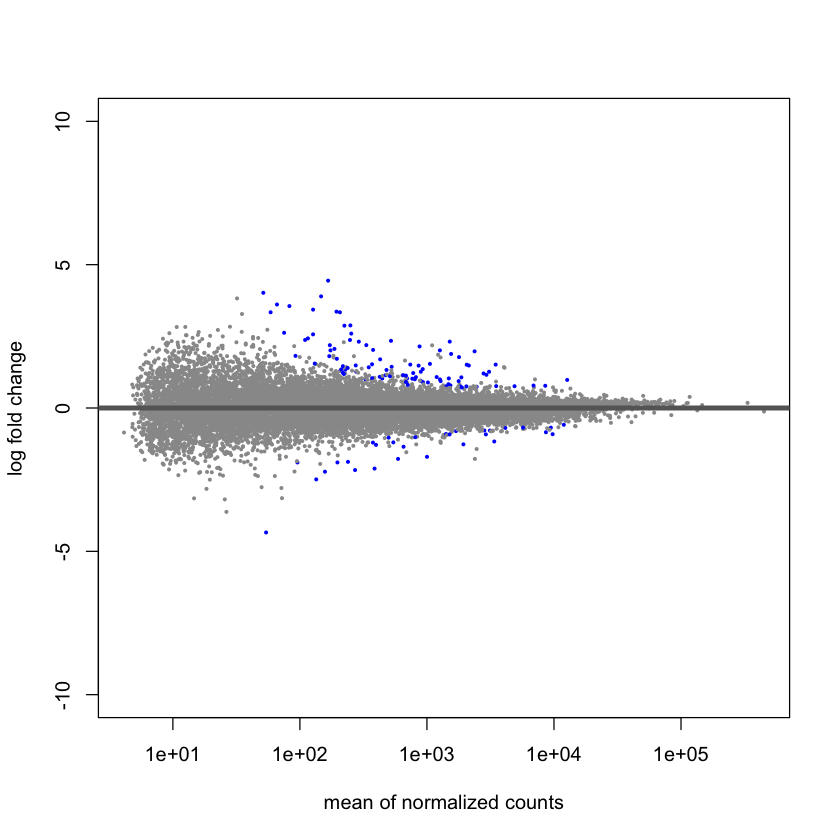

In [57]:
# Compare the mutants to N, and report genes that have padj<0.05. 
# contrast = c("condition", "treated", "nontreated")
# This contrast should report negative log2FC if expression is down in the mutant 
res <- results(dds, contrast=c("Treatment","IAA","Control"), alpha=0.05)
summary(res); #summary
plotMA(res,ylim=c(-10,10)); #smearplot
res

# filter to sigDE genes 
dim(res)
sigDE <- subset (res, padj<0.05)
dim(sigDE)

# Export 
write.table(as.data.frame(sigDE), 
            file="./NormalSibs_IAAvsControl_AuxinApex_sigDE.txt",
            sep="\t", quote=F)


In [58]:
library(goseq)

Loading required package: BiasedUrn

Loading required package: geneLenDataBase


Attaching package: ‘geneLenDataBase’


The following object is masked from ‘package:S4Vectors’:

    unfactor






In [60]:


# First need to generate a table with all of the genes in 1 column and then either 1 for DE or 0 for not DE in a second column
#extract gene list 
# First extract a list of all of the genes in the dataset - this is in the counts file 
dim(counts)
counts_rownames <- rownames(counts)
assayed.genes <- counts_rownames#genes [1]
dim(assayed.genes)

# Then extract a list of all of the sigDE gene names from sigDE
dim(sigDE)
sigDE_rownames <- rownames(sigDE)
de.genes <- sigDE_rownames
dim(de.genes)

# Then create a vector that has gene names asscoiated with e 1 or 0 base don it they are in both of the baove lists 
gene.vector=as.integer(assayed.genes%in%de.genes)
names(gene.vector)=assayed.genes
head(gene.vector)


[1] 39756     4

NULL

[1] 125   6

NULL

Zm00001eb000010 Zm00001eb000020 Zm00001eb000050 Zm00001eb000060 Zm00001eb000070 
              0               0               0               0               0 
Zm00001eb000080 
              0

In [61]:
# Need to make a gene length file - this info is in column 6 of the featureCounts file
featureCounts <- read.table(file_paths[1], sep="\t", header=T) # start by reading the first file
lengths <- cbind(featureCounts[,6]) # take the 6th column (counts)
rownames(lengths) <- featureCounts[,1] # name by gene

colnames(lengths) <- c('gene.length') # name the first column

head(lengths) # check on the data
dim(featureCounts) # before
dim(lengths) # after

#Remove the "gene:" from the start of the gene names 
 #head( sub("gene:", "", rownames(counts)) )
rownames(lengths) <- sub("gene:", "", rownames(lengths))
head(lengths)

# Format lengths to be like genes.vector
# First need to generate a table with all of the genes in 1 column and then either 1 for DE or 0 for not DE in a second column
#extract gene list 
 #get rownames 
lengths_rownames <- rownames (lengths)
head(lengths_rownames)
#convert rownames to column
gene.lengths <- cbind(rownames(lengths), data.frame(lengths, row.names=NULL))
head(gene.lengths)

head(gene.lengths)

# Convert the table to a named vector list
library(tibble)
gene.lengths.vector <- deframe(gene.lengths)
head(gene.lengths.vector)

,gene.length
Zm00001eb000010,3615
Zm00001eb000020,3318
Zm00001eb000050,1077
Zm00001eb000060,966
Zm00001eb000070,774
Zm00001eb000080,1738


[1] 39756     7

[1] 39756     1

,gene.length
Zm00001eb000010,3615
Zm00001eb000020,3318
Zm00001eb000050,1077
Zm00001eb000060,966
Zm00001eb000070,774
Zm00001eb000080,1738


[1] "Zm00001eb000010" "Zm00001eb000020" "Zm00001eb000050" "Zm00001eb000060"
[5] "Zm00001eb000070" "Zm00001eb000080"

,rownames(lengths),gene.length
,<chr>,<int>
1,Zm00001eb000010,3615
2,Zm00001eb000020,3318
3,Zm00001eb000050,1077
4,Zm00001eb000060,966
5,Zm00001eb000070,774
6,Zm00001eb000080,1738


,rownames(lengths),gene.length
,<chr>,<int>
1,Zm00001eb000010,3615
2,Zm00001eb000020,3318
3,Zm00001eb000050,1077
4,Zm00001eb000060,966
5,Zm00001eb000070,774
6,Zm00001eb000080,1738


Zm00001eb000010 Zm00001eb000020 Zm00001eb000050 Zm00001eb000060 Zm00001eb000070 
           3615            3318            1077             966             774 
Zm00001eb000080 
           1738

,DEgenes,bias.data,pwf
,<int>,<int>,<dbl>
Zm00001eb000010,0,3615,0.003137263
Zm00001eb000020,0,3318,0.003318593
Zm00001eb000050,0,1077,0.004379449
Zm00001eb000060,0,966,0.004379456
Zm00001eb000070,0,774,0.004379472
Zm00001eb000080,0,1738,0.004352743


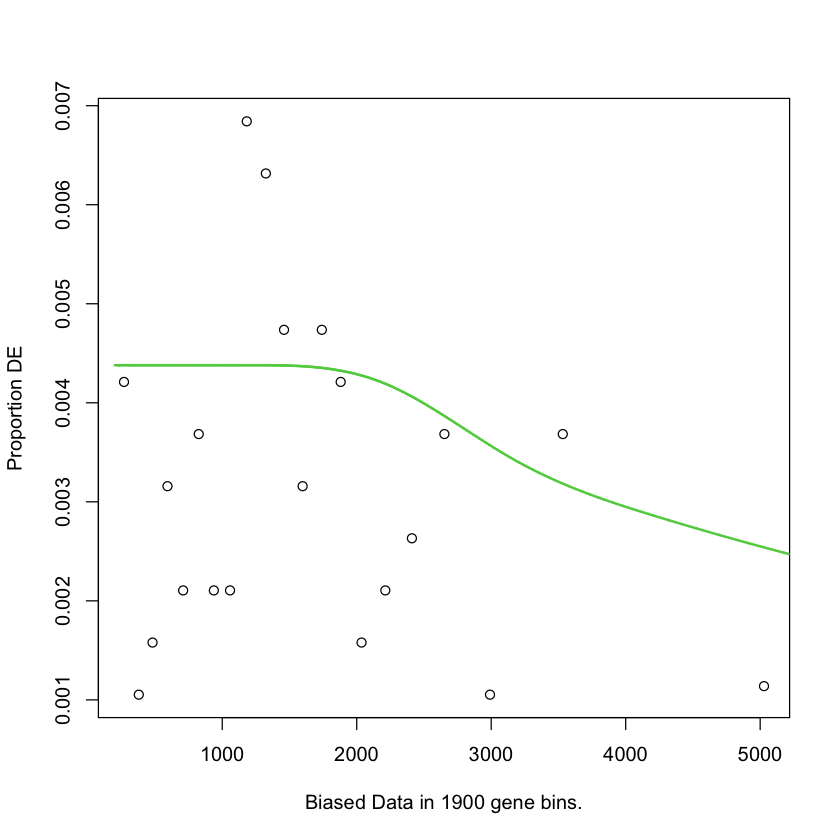

In [62]:
#To begin the analysis, goseq first needs to quantify the length bias present in the dataset under
#consideration. This is done by calculating a Probability Weighting Function or PWF which can
#be thought of as a function which gives the probability that a gene will be differentially expressed
#(DE), based on its length alone. The PWF is calculated by fitting a monotonic spline to the binary
#data series of differential expression (1=DE, 0=Not DE) as a function of gene length. The PWF is
#used to weight the chance of selecting each gene when forming a null distribution for GO category
#membership. 
# nullp(DEgenes, genome, id, bias.data=NULL,plot.fit=TRUE)
pwf=nullp(gene.vector, bias.data=gene.lengths.vector,plot.fit=TRUE)
head(pwf)

In [64]:
# Next need to get the GO terms associated with the gene names for the maize B73v3 genome 
# Madelaines lab use the GO terms from maize-PANNZER GO in maize-GAMER 
# downloaded maize_v3.agg.nr.gaf from /iplant/home/shared/commons_repo/curated/Carolyn_Lawrence_Dill_maize-GAMER_July_2017_V.1/e._agg_data
# Load the GAF file (needed ot first remove the first line which just states the version of gaf file it is using text editor )
maizeGO<-read.table("/Users/aricha14/Desktop/Trf_Auxin/Maize_GAMER_GO terms/3.1_B73v5.MaizeGDB.CLEANED.gaf", header=TRUE, sep='\t')
head(maizeGO)
# Generate the GO catgeory list 
# extract column 2 and 4 from the maizeGo table 
GO<-data.frame(maizeGO$db_object_id,maizeGO$term_accession)
head(GO)


,X.db,db_object_id,db_object_symbol,qualifier,term_accession,db_reference,evidence_code,with,aspect,db_object_name,db_object_synonym,db_object_type,taxon,date,assigned_by,annotation_extension,gene_product_form_id
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,MaizeGDB_maize,Zm00001eb000010,Zm00001eb000010,,GO:0003690,GOMAP:0000,IEA,,F,NA,NA,gene,taxon:4577,20211230,GOMAP_v1.3.8,,Zm00001eb000010
2,MaizeGDB_maize,Zm00001eb000010,Zm00001eb000010,,GO:0003727,GOMAP:0000,IEA,RBH:I1IST9,F,NA,NA,gene,taxon:4577,20211215,GOMAP_v1.3.8,,Zm00001eb000010
3,MaizeGDB_maize,Zm00001eb000010,Zm00001eb000010,,GO:0019843,GOMAP:0000,IEA,RBH:I1IST9,F,NA,NA,gene,taxon:4577,20211215,GOMAP_v1.3.8,,Zm00001eb000010
4,MaizeGDB_maize,Zm00001eb000010,Zm00001eb000010,,GO:0005739,GOMAP:0000,IEA,RBH:AT1G78930,C,NA,NA,gene,taxon:4577,20211215,GOMAP_v1.3.8,,Zm00001eb000010
5,MaizeGDB_maize,Zm00001eb000010,Zm00001eb000010,,GO:0009507,GOMAP:0000,IEA,RBH:AT1G78930,C,NA,NA,gene,taxon:4577,20211215,GOMAP_v1.3.8,,Zm00001eb000010
6,MaizeGDB_maize,Zm00001eb000010,Zm00001eb000010,,GO:0006355,GOMAP:0000,IEA,,P,NA,NA,gene,taxon:4577,20211230,GOMAP_v1.3.8,,Zm00001eb000010


,maizeGO.db_object_id,maizeGO.term_accession
,<chr>,<chr>
1,Zm00001eb000010,GO:0003690
2,Zm00001eb000010,GO:0003727
3,Zm00001eb000010,GO:0019843
4,Zm00001eb000010,GO:0005739
5,Zm00001eb000010,GO:0009507
6,Zm00001eb000010,GO:0006355


In [65]:
# Now we have have ajusted bias base don gene lengths (pwf) and have an appropriately formatted GO list
# we can run the enrichment test using goseq
GO.wall = goseq(pwf, gene2cat = GO, method = "Wallenius", repcnt = 2000, use_genes_without_cat=FALSE)
GO.wall

Using manually entered categories.

Calculating the p-values...

'select()' returned 1:1 mapping between keys and columns



,category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology
,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>
2914,GO:0009734,1.696840e-18,1.0000000,19,360,auxin-activated signaling pathway,BP
1315,GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF
6878,GO:0046620,5.780367e-10,1.0000000,5,14,regulation of organ growth,BP
3047,GO:0009926,1.731838e-06,0.9999999,7,195,auxin polar transport,BP
3132,GO:0010046,3.812978e-06,1.0000000,3,11,response to mycotoxin,BP
8230,GO:0070566,5.199957e-06,1.0000000,3,12,adenylyltransferase activity,MF
2790,GO:0009536,6.264789e-06,0.9999994,8,305,plastid,CC
8645,GO:0080123,7.043871e-06,0.9999999,3,13,jasmonate-amino synthetase activity,MF
7196,GO:0048438,8.089472e-06,0.9999998,4,40,floral whorl development,BP


In [66]:
#Having performed the GO analysis, you may now wish to interpret the results. If you wish to
#identify categories significantly enriched/unenriched below some p-value cutoff, it is necessary to
#first apply some kind of multiple hypothesis testing correction. For example, GO categories over
#enriched using a .05 FDR cutoff [Benjamini and Hochberg, 1995] are:
# Find statistically enriched GO terms 
enriched.GO=GO.wall$category[p.adjust(GO.wall$over_represented_pvalue, method="BH")<.05]
enriched.GO

[1] "GO:0009734" "GO:0005516" "GO:0046620" "GO:0009926" "GO:0010046"
 [6] "GO:0070566" "GO:0009536" "GO:0080123" "GO:0048438" "GO:2000030"
[11] "GO:0009861" "GO:0009694" "GO:0009741"

In [67]:
#Need to add a new column with adjusted pvalues for over-represented GO terms 
library(dplyr)
GO.wall.padj<-GO.wall
GO.wall.padj <- (GO.wall.padj %>% mutate (padj = (p.adjust(GO.wall.padj$over_represented_pvalue, method="BH")) ))
dim(GO.wall.padj)
head(GO.wall.padj)

[1] 9345    8

,category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj
,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>
2914,GO:0009734,1.696840e-18,1.0000000,19,360,auxin-activated signaling pathway,BP,1.585697e-14
1315,GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF,2.262125e-08
6878,GO:0046620,5.780367e-10,1.0000000,5,14,regulation of organ growth,BP,1.800584e-06
3047,GO:0009926,1.731838e-06,0.9999999,7,195,auxin polar transport,BP,4.046008e-03
3132,GO:0010046,3.812978e-06,1.0000000,3,11,response to mycotoxin,BP,7.126455e-03
8230,GO:0070566,5.199957e-06,1.0000000,3,12,adenylyltransferase activity,MF,8.098934e-03


In [68]:
# Next filter these for significantly enriched 
GO.enriched <- subset (GO.wall.padj, padj <0.05)
dim(GO.enriched)
head(GO.enriched)

[1] 13  8

,category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj
,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>
2914,GO:0009734,1.696840e-18,1.0000000,19,360,auxin-activated signaling pathway,BP,1.585697e-14
1315,GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF,2.262125e-08
6878,GO:0046620,5.780367e-10,1.0000000,5,14,regulation of organ growth,BP,1.800584e-06
3047,GO:0009926,1.731838e-06,0.9999999,7,195,auxin polar transport,BP,4.046008e-03
3132,GO:0010046,3.812978e-06,1.0000000,3,11,response to mycotoxin,BP,7.126455e-03
8230,GO:0070566,5.199957e-06,1.0000000,3,12,adenylyltransferase activity,MF,8.098934e-03


In [69]:
# Most people plot -log2 adjusted p values 
# so need to add these now 
GO_minuslogpvalues <- (GO.enriched %>% mutate (-log(padj)))
dim(GO_minuslogpvalues)
head(GO_minuslogpvalues)
# This is a table of the signifcantly enriched GO terms based on adjusted P values, with corresponding -logpadj values for plotting 

[1] 13  9

,category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj,-log(padj)
,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>
2914,GO:0009734,1.696840e-18,1.0000000,19,360,auxin-activated signaling pathway,BP,1.585697e-14,31.775167
1315,GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF,2.262125e-08,17.604376
6878,GO:0046620,5.780367e-10,1.0000000,5,14,regulation of organ growth,BP,1.800584e-06,13.227399
3047,GO:0009926,1.731838e-06,0.9999999,7,195,auxin polar transport,BP,4.046008e-03,5.510025
3132,GO:0010046,3.812978e-06,1.0000000,3,11,response to mycotoxin,BP,7.126455e-03,4.943941
8230,GO:0070566,5.199957e-06,1.0000000,3,12,adenylyltransferase activity,MF,8.098934e-03,4.816023


In [84]:
# Most GO term enrichment plots have -logpadj mapped for each GO term plus a factor called zscore determining colouration
# zscore is #zscore=(up−down)/√count
# To calculate zscore for each GO term I need
#(1) GO terms with otal number of genes in the dataset (numDEInCat om above table)
# (2) GO terms with number of genes DOWN
# (3) GO terms with numer of genes UP 
# To do this I first need to generate a table with genes, thier GO terms, and log2Foldchnages 
# First enerate a table of SIgDE genes with their log2FC values
head(sigDE)
# first need to convert rownames to a column
#get rownames 
rownames <- rownames (sigDE)
#convert rownames to column
sigDE_genes <- cbind(rownames(sigDE), data.frame(sigDE, row.names=NULL))
head(sigDE_genes)


log2 fold change (MLE): Treatment IAA vs Control 
Wald test p-value: Treatment IAA vs Control 
DataFrame with 6 rows and 6 columns
                 baseMean log2FoldChange     lfcSE      stat      pvalue
                <numeric>      <numeric> <numeric> <numeric>   <numeric>
Zm00001eb004490  2462.936       0.740668  0.186646   3.96829 7.23891e-05
Zm00001eb006210  4892.580       0.759455  0.179229   4.23734 2.26183e-05
Zm00001eb006930   697.983       1.032466  0.251192   4.11026 3.95210e-05
Zm00001eb014120  9451.365      -0.685548  0.180805  -3.79164 1.49656e-04
Zm00001eb017400   227.297       1.329987  0.358394   3.71097 2.06471e-04
Zm00001eb019460  1865.981       1.068916  0.191158   5.59180 2.24723e-08
                       padj
                  <numeric>
Zm00001eb004490 1.88442e-02
Zm00001eb006210 7.01229e-03
Zm00001eb006930 1.17813e-02
Zm00001eb014120 3.23516e-02
Zm00001eb017400 4.06852e-02
Zm00001eb019460 1.68557e-05

,rownames(sigDE),baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Zm00001eb004490,2462.9358,0.7406677,0.1866464,3.968294,7.238909e-05,1.884423e-02
2,Zm00001eb006210,4892.5801,0.7594554,0.1792293,4.237340,2.261833e-05,7.012285e-03
3,Zm00001eb006930,697.9829,1.0324662,0.2511923,4.110262,3.952098e-05,1.178130e-02
4,Zm00001eb014120,9451.3653,-0.6855480,0.1808051,-3.791640,1.496558e-04,3.235155e-02
5,Zm00001eb017400,227.2967,1.3299865,0.3583937,3.710965,2.064706e-04,4.068521e-02
6,Zm00001eb019460,1865.9807,1.0689156,0.1911576,5.591804,2.247230e-08,1.685567e-05


In [85]:
# extract the gene names plus the log2Foldchange 
dim(sigDE_genes)
genes <- data.frame(sigDE_genes$rownames,sigDE_genes$log2FoldChange)
dim(genes)
head(genes)
# rename the columns
names(genes)[1] <- "Gene"
names(genes)[2] <- "log2FoldChange"
head(genes)

[1] 125   7

[1] 125   2

,sigDE_genes.rownames,sigDE_genes.log2FoldChange
,<chr>,<dbl>
1,Zm00001eb004490,0.7406677
2,Zm00001eb006210,0.7594554
3,Zm00001eb006930,1.0324662
4,Zm00001eb014120,-0.6855480
5,Zm00001eb017400,1.3299865
6,Zm00001eb019460,1.0689156


,Gene,log2FoldChange
,<chr>,<dbl>
1,Zm00001eb004490,0.7406677
2,Zm00001eb006210,0.7594554
3,Zm00001eb006930,1.0324662
4,Zm00001eb014120,-0.6855480
5,Zm00001eb017400,1.3299865
6,Zm00001eb019460,1.0689156


In [86]:
# Next make a table that has the genes, GO terms and GO padj values 
# Look in GO for rows that have matching category values in GO_minuslogpvalues
# then merge the two tables 
head(GO)
# reformat the oclumn names in GO to match 
names(GO)[1] <- "Gene"
names(GO)[2] <- "category"
head(GO)

# Then look for the matching genes in the GO_minuslogpavlues table and make a new df
GO_enriched_genes <- merge (GO, GO_minuslogpvalues, by.x ="category")

dim(GO_enriched_genes)
head(GO_enriched_genes)

# So this is a table of all the genes that are assocoated with a GO term that is significantly enriched in my SigDE list
# Includes the statistical tests to confirm the GO term enrichment 

,Gene,category
,<chr>,<chr>
1,Zm00001eb000010,GO:0003690
2,Zm00001eb000010,GO:0003727
3,Zm00001eb000010,GO:0019843
4,Zm00001eb000010,GO:0005739
5,Zm00001eb000010,GO:0009507
6,Zm00001eb000010,GO:0006355


,Gene,category
,<chr>,<chr>
1,Zm00001eb000010,GO:0003690
2,Zm00001eb000010,GO:0003727
3,Zm00001eb000010,GO:0019843
4,Zm00001eb000010,GO:0005739
5,Zm00001eb000010,GO:0009507
6,Zm00001eb000010,GO:0006355


[1] 1505   10

,category,Gene,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj,-log(padj)
,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>
1,GO:0005516,Zm00001eb209160,4.84136e-12,1,13,295,calmodulin binding,MF,2.262125e-08,17.60438
2,GO:0005516,Zm00001eb315470,4.84136e-12,1,13,295,calmodulin binding,MF,2.262125e-08,17.60438
3,GO:0005516,Zm00001eb104090,4.84136e-12,1,13,295,calmodulin binding,MF,2.262125e-08,17.60438
4,GO:0005516,Zm00001eb075970,4.84136e-12,1,13,295,calmodulin binding,MF,2.262125e-08,17.60438
5,GO:0005516,Zm00001eb040610,4.84136e-12,1,13,295,calmodulin binding,MF,2.262125e-08,17.60438
6,GO:0005516,Zm00001eb318420,4.84136e-12,1,13,295,calmodulin binding,MF,2.262125e-08,17.60438


In [87]:
# Using these two tables, create one that has the sigDE genes with their GO terms, and log2FC
FC_GO <- merge (GO_enriched_genes, genes, by="Gene")
dim(FC_GO)
head (FC_GO)
# This is a table with the sigDE genes that have a GO term that is significantly over represented in the BP category
# With associated padj values for the GO term enrichment and log2FoldChnage for the SigDE analysis 


[1] 81 11

,Gene,category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj,-log(padj),log2FoldChange
,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,Zm00001eb040680,GO:0009536,6.264789e-06,0.9999994,8,305,plastid,CC,8.228122e-03,4.800197,1.027566
2,Zm00001eb040680,GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF,2.262125e-08,17.604376,1.027566
3,Zm00001eb040680,GO:0009734,1.696840e-18,1.0000000,19,360,auxin-activated signaling pathway,BP,1.585697e-14,31.775167,1.027566
4,Zm00001eb051060,GO:0009741,2.390374e-05,0.9999982,6,177,response to brassinosteroid,BP,1.718311e-02,4.063828,2.315764
5,Zm00001eb051060,GO:0009536,6.264789e-06,0.9999994,8,305,plastid,CC,8.228122e-03,4.800197,2.315764
6,Zm00001eb051060,GO:0009926,1.731838e-06,0.9999999,7,195,auxin polar transport,BP,4.046008e-03,5.510025,2.315764


In [88]:
# Now we have this table we can calculate counts of Up, Down and total genes for each GO category
# extract number of genes with the GO term 
FC_GO_df <- count(FC_GO, category)
head (FC_GO_df)
dim(FC_GO_df)


# generate df with genes with GO terms that are DOWN or UP based on log2Foldchnage 
FC_DOWN <- subset (FC_GO, log2FoldChange < 0)
dim(FC_DOWN)
FC_UP <- subset (FC_GO, log2FoldChange > 0)
dim (FC_UP)

# count the number of genes with the GO term 
df_FC_DOWN <- count(FC_DOWN, category)
head (df_FC_DOWN)
dim(df_FC_DOWN)
df_FC_UP <- count(FC_UP, category)
head (df_FC_UP)
dim(df_FC_UP)

,category,n
,<chr>,<int>
1,GO:0005516,13
2,GO:0009536,8
3,GO:0009694,4
4,GO:0009734,19
5,GO:0009741,6
6,GO:0009861,3


[1] 13  2

[1]  5 11

[1] 76 11

,category,n
,<chr>,<int>
1,GO:0005516,1
2,GO:0009536,1
3,GO:0048438,3


[1] 3 2

,category,n
,<chr>,<int>
1,GO:0005516,12
2,GO:0009536,7
3,GO:0009694,4
4,GO:0009734,19
5,GO:0009741,6
6,GO:0009861,3


[1] 13  2

In [89]:
# reformat the column names in GO to match 
names(df_FC_UP)[2] <- "UP_freq"
head(df_FC_UP)
names(df_FC_DOWN)[2] <- "DOWN_freq"
head(df_FC_DOWN)


,category,UP_freq
,<chr>,<int>
1,GO:0005516,12
2,GO:0009536,7
3,GO:0009694,4
4,GO:0009734,19
5,GO:0009741,6
6,GO:0009861,3


,category,DOWN_freq
,<chr>,<int>
1,GO:0005516,1
2,GO:0009536,1
3,GO:0048438,3


In [97]:
# Add UP counts to the table 
FC_GO_data_UP <- merge (GO_minuslogpvalues, df_FC_UP, by.x ="category")
dim(FC_GO_data_UP)
head(FC_GO_data_UP)

[1] 13 10

,category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj,-log(padj),UP_freq
,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>
1,GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF,2.262125e-08,17.604376,12
2,GO:0009536,6.264789e-06,0.9999994,8,305,plastid,CC,8.228122e-03,4.800197,7
3,GO:0009694,2.361439e-05,0.9999993,4,53,jasmonic acid metabolic process,BP,1.718311e-02,4.063828,4
4,GO:0009734,1.696840e-18,1.0000000,19,360,auxin-activated signaling pathway,BP,1.585697e-14,31.775167,19
5,GO:0009741,2.390374e-05,0.9999982,6,177,response to brassinosteroid,BP,1.718311e-02,4.063828,6
6,GO:0009861,1.325403e-05,0.9999999,3,16,jasmonic acid and ethylene-dependent systemic resistance,BP,1.125990e-02,4.486507,3


In [99]:
# Then add DOWN counts to the table 
FC_GO_data_D <- merge (GO_minuslogpvalues, df_FC_DOWN, by.x ="category")
dim(FC_GO_data_D)
head(FC_GO_data_D)

[1]  3 10

,category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj,-log(padj),DOWN_freq
,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>
1,GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF,2.262125e-08,17.604376,1
2,GO:0009536,6.264789e-06,0.9999994,8,305,plastid,CC,8.228122e-03,4.800197,1
3,GO:0048438,8.089472e-06,0.9999998,4,40,floral whorl development,BP,8.399569e-03,4.779575,3


In [106]:
FC_GO_data<- full_join(FC_GO_data_UP,FC_GO_data_D)
dim(FC_GO_data)
FC_GO_data

Joining with `by = join_by(category, over_represented_pvalue,
under_represented_pvalue, numDEInCat, numInCat, term, ontology, padj,
`-log(padj)`)`


[1] 13 11

category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj,-log(padj),UP_freq,DOWN_freq
<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>
GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF,2.262125e-08,17.604376,12,1
GO:0009536,6.264789e-06,0.9999994,8,305,plastid,CC,8.228122e-03,4.800197,7,1
GO:0009694,2.361439e-05,0.9999993,4,53,jasmonic acid metabolic process,BP,1.718311e-02,4.063828,4,NA
GO:0009734,1.696840e-18,1.0000000,19,360,auxin-activated signaling pathway,BP,1.585697e-14,31.775167,19,NA
GO:0009741,2.390374e-05,0.9999982,6,177,response to brassinosteroid,BP,1.718311e-02,4.063828,6,NA
GO:0009861,1.325403e-05,0.9999999,3,16,jasmonic acid and ethylene-dependent systemic resistance,BP,1.125990e-02,4.486507,3,NA
GO:0009926,1.731838e-06,0.9999999,7,195,auxin polar transport,BP,4.046008e-03,5.510025,7,NA
GO:0010046,3.812978e-06,1.0000000,3,11,response to mycotoxin,BP,7.126455e-03,4.943941,3,NA
GO:0046620,5.780367e-10,1.0000000,5,14,regulation of organ growth,BP,1.800584e-06,13.227399,5,NA


In [107]:
# convert NA to 0
FC_GO_data <- FC_GO_data %>% replace(is.na(.), 0)
FC_GO_data

category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj,-log(padj),UP_freq,DOWN_freq
<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>
GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF,2.262125e-08,17.604376,12,1
GO:0009536,6.264789e-06,0.9999994,8,305,plastid,CC,8.228122e-03,4.800197,7,1
GO:0009694,2.361439e-05,0.9999993,4,53,jasmonic acid metabolic process,BP,1.718311e-02,4.063828,4,0
GO:0009734,1.696840e-18,1.0000000,19,360,auxin-activated signaling pathway,BP,1.585697e-14,31.775167,19,0
GO:0009741,2.390374e-05,0.9999982,6,177,response to brassinosteroid,BP,1.718311e-02,4.063828,6,0
GO:0009861,1.325403e-05,0.9999999,3,16,jasmonic acid and ethylene-dependent systemic resistance,BP,1.125990e-02,4.486507,3,0
GO:0009926,1.731838e-06,0.9999999,7,195,auxin polar transport,BP,4.046008e-03,5.510025,7,0
GO:0010046,3.812978e-06,1.0000000,3,11,response to mycotoxin,BP,7.126455e-03,4.943941,3,0
GO:0046620,5.780367e-10,1.0000000,5,14,regulation of organ growth,BP,1.800584e-06,13.227399,5,0


In [108]:
# Next calculate zscore and make a new column with the result
#zscore=(up−down)/√count
FC_GO_data$zscore <- (FC_GO_data$UP_freq - FC_GO_data$DOWN_freq)/ sqrt(FC_GO_data$numDEInCat)
dim(FC_GO_data)
head(FC_GO_data)

# This is a table that has every sigDE gene, with the associated enriched GO term, adj p value for GO enrichements, and zscore 

[1] 13 12

,category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj,-log(padj),UP_freq,DOWN_freq,zscore
,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF,2.262125e-08,17.604376,12,1,3.050851
2,GO:0009536,6.264789e-06,0.9999994,8,305,plastid,CC,8.228122e-03,4.800197,7,1,2.121320
3,GO:0009694,2.361439e-05,0.9999993,4,53,jasmonic acid metabolic process,BP,1.718311e-02,4.063828,4,0,2.000000
4,GO:0009734,1.696840e-18,1.0000000,19,360,auxin-activated signaling pathway,BP,1.585697e-14,31.775167,19,0,4.358899
5,GO:0009741,2.390374e-05,0.9999982,6,177,response to brassinosteroid,BP,1.718311e-02,4.063828,6,0,2.449490
6,GO:0009861,1.325403e-05,0.9999999,3,16,jasmonic acid and ethylene-dependent systemic resistance,BP,1.125990e-02,4.486507,3,0,1.732051


In [109]:
# Try changing the oclour scheme
library(RColorBrewer)
colors <- colorRampPalette( brewer.pal(9, "PRGn") )(255)

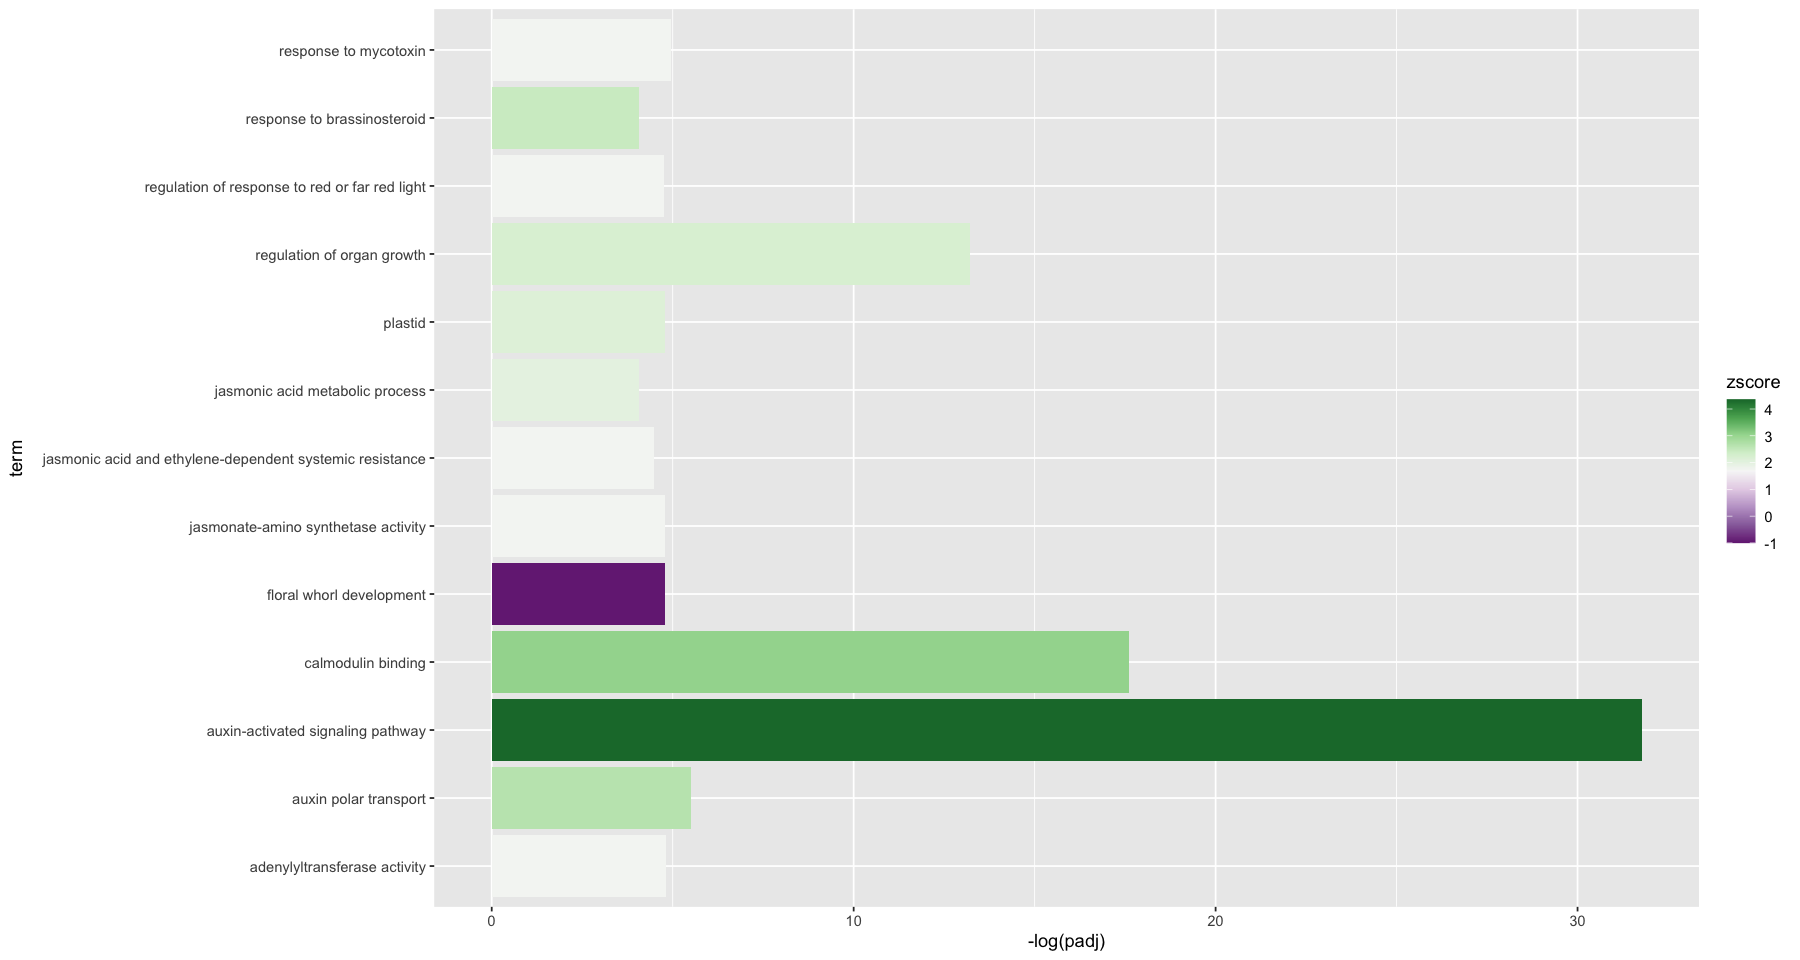

[1] "This is a GO term enrichment plot of all sigDE genes between IAA and control N sibs"

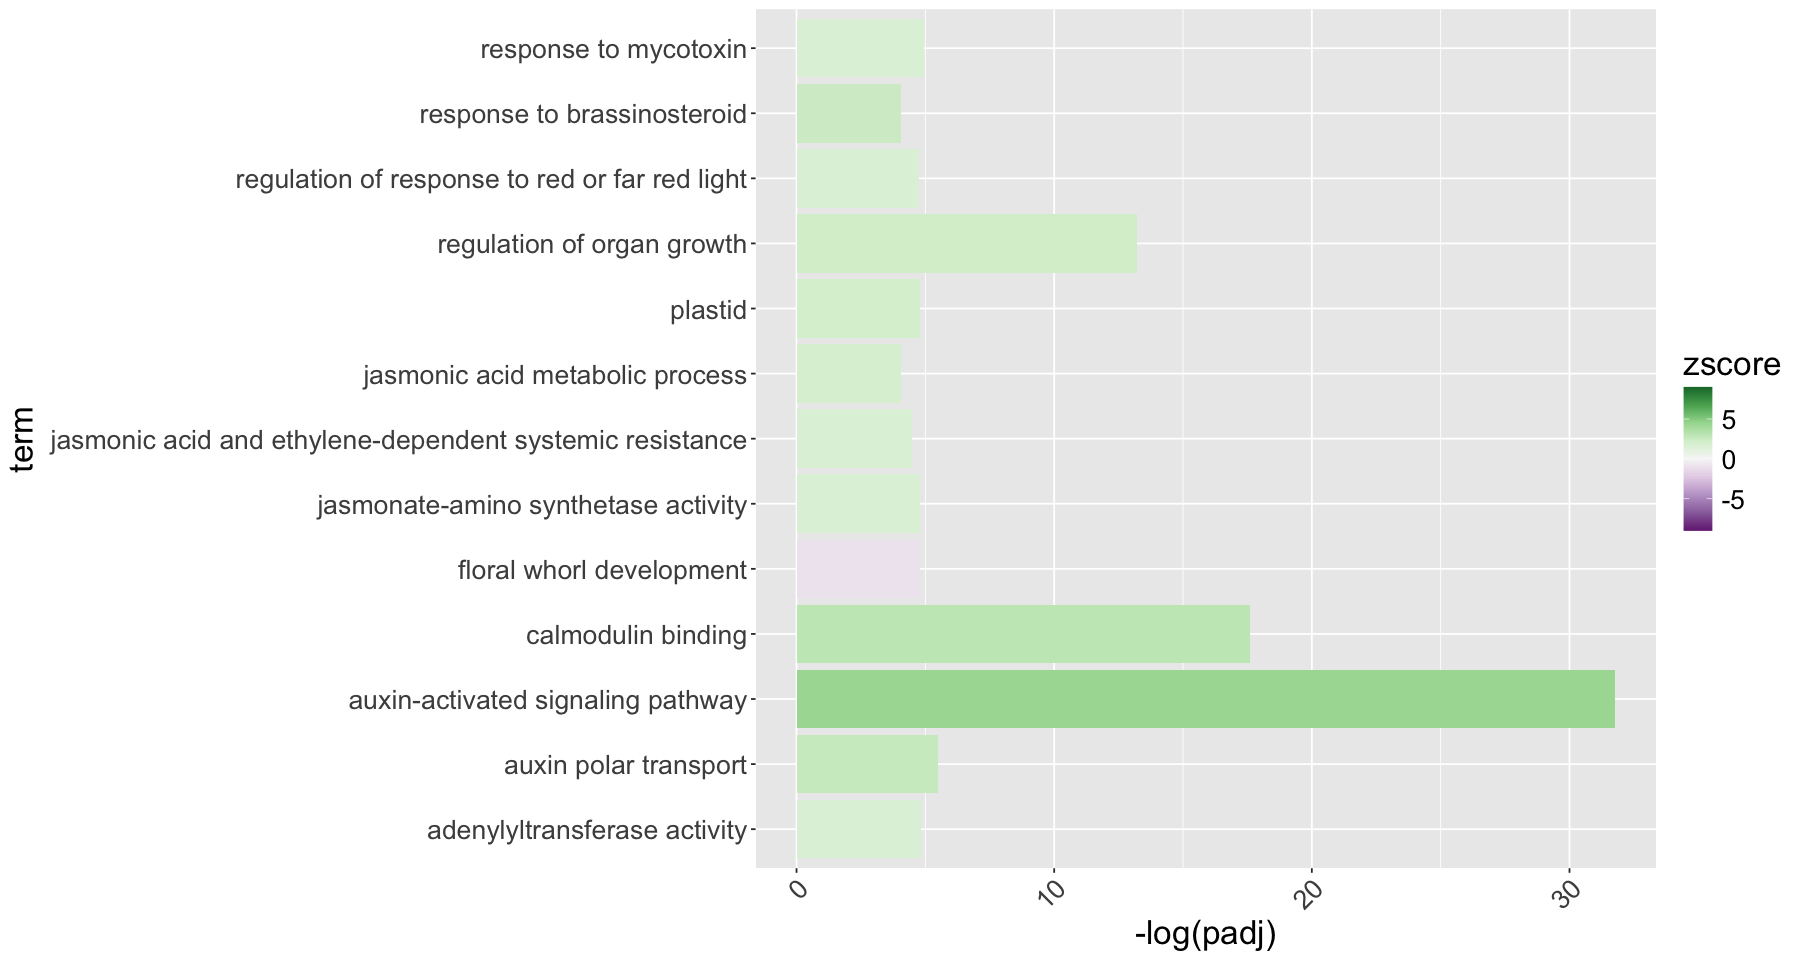

In [110]:
# OK so lets now plot the bar chart with the z score as the colour coding
# plot a simple bar graph of the data in GO_data with terms along the x axis and -logPadj in the Y
library(ggplot2)
GOplot <- ggplot (FC_GO_data, aes (term, -log(padj)))
# make a bar plot and flip to make it horizontal 
options(repr.plot.width=15, repr.plot.height=8)
GOplot + geom_col(aes(fill=zscore)) + coord_flip () + scale_fill_gradientn(colours=colors)
GOplot + geom_col(aes(fill=zscore)) + coord_flip () + scale_fill_gradientn( limits = c(-9,9),colours=colors) +  theme(text = element_text(size=20), axis.text.x = element_text(angle=45, hjust=1)) 

"This is a GO term enrichment plot of all sigDE genes between IAA and control N sibs"

So the 30min IAA treatment in N siblings does have an auxin response, which generally shows higher expression of these genes 


# Now analyse the Trf siblings 


In [134]:
list.files(directory)
# Define the paths to the read files 
file_names <- list.files(path=directory, pattern = "*.txt") # create a list of all txt files in the "Tassel_stage1_counts" folder
file_paths <- list.files(path=directory, pattern = "*.txt", full.names=T) # create a list of all txt files' full locations
print(file_names)
print(file_paths)
# Building the counts table 
featureCounts <- read.table(file_paths[1], sep="\t", header=T) # start by reading the first file
#look at the first first file
dim(featureCounts)
head(featureCounts, 10)

[1] "TRF_C_1_EKRN240043747-1A_22F2GWLT4_L7.counts.txt"  
[2] "TRF_C_2_EKRN240043748-1A_22F2GWLT4_L7.counts.txt"  
[3] "TRF_IAA_1_EKRN240043744-1A_22F2GWLT4_L7.counts.txt"
[4] "TRF_IAA_3_EKRN240043746-1A_22F2GWLT4_L7.counts.txt"

[1] "TRF_C_1_EKRN240043747-1A_22F2GWLT4_L7.counts.txt"  
[2] "TRF_C_2_EKRN240043748-1A_22F2GWLT4_L7.counts.txt"  
[3] "TRF_IAA_1_EKRN240043744-1A_22F2GWLT4_L7.counts.txt"
[4] "TRF_IAA_3_EKRN240043746-1A_22F2GWLT4_L7.counts.txt"
[1] "./featureCounts/TRF_C_1_EKRN240043747-1A_22F2GWLT4_L7.counts.txt"  
[2] "./featureCounts/TRF_C_2_EKRN240043748-1A_22F2GWLT4_L7.counts.txt"  
[3] "./featureCounts/TRF_IAA_1_EKRN240043744-1A_22F2GWLT4_L7.counts.txt"
[4] "./featureCounts/TRF_IAA_3_EKRN240043746-1A_22F2GWLT4_L7.counts.txt"


[1] 39756     7

,Geneid,Chr,Start,End,Strand,Length,..Desktop.TRF_AUXIN_RNAseq_July2024.aligned_reads.TRF_C_1_EKRN240043747.1A_22F2GWLT4_L7.bam
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
1,Zm00001eb000010,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,34617;36037;36259;36600;36822;37416;38021;38571;39701,35318;36174;36504;36713;37004;37633;38482;39618;40204,+;+;+;+;+;+;+;+;+,3615,934
2,Zm00001eb000020,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,41214;41214;41263;41314;41742;41742;41742;41742;42257;42257;42257;42508;42508;42508;42508;42762;42762;42762;42762;43039;43039;43039;43039;43318;43318;43318;43318;43750;43750;43994;43994;43994;45593;45593;45593,41588;41588;41588;41588;41807;42375;41807;41807;42375;42375;42375;42665;42665;42665;42665;42917;42917;42917;42917;43197;43197;43197;43197;43520;43520;43520;43520;43802;43902;44303;44303;44303;46039;46050;46762,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-,3318,8924
3,Zm00001eb000050,chr1;chr1;chr1;chr1;chr1;chr1;chr1,108554;109172;109340;109498;109706;109882;113762,108564;109264;109411;109622;109790;109951;114382,-;-;-;-;-;-;-,1077,0
4,Zm00001eb000060,chr1;chr1,188559;189146,189088;189581,-;-,966,1079
5,Zm00001eb000070,chr1;chr1;chr1;chr1;chr1;chr1,190192;190301;190624;191350;197313;198535,190199;190561;190681;191442;197368;198832,-;-;-;-;-;-,774,5
6,Zm00001eb000080,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,200262;200916;201124;201433;201662;201912;202483;203022;203302,200810;201043;201211;201571;201838;202158;202592;203229;203393,-;-;-;-;-;-;-;-;-,1738,2059
7,Zm00001eb000100,chr1;chr1;chr1;chr1;chr1;chr1,206619;207090;207447;207679;208377;209221,206995;207244;207582;207819;208969;209723,-;-;-;-;-;-,1905,4
8,Zm00001eb000110,chr1;chr1,246422;246997,246545;247242,-;-,370,0
9,Zm00001eb000120,chr1,315219,315846,+,628,2


In [135]:
featureCounts <- read.table(file_paths[1], sep="\t", header=T) # start by reading the first file
counts <- cbind(featureCounts[,7]) # take the 7th column (counts)
rownames(counts) <- featureCounts[,1] # name by gene

colnames(counts) <- c(file_names[1]) # name the first column

head(counts) # check on the data
dim(featureCounts) # before
dim(counts) # after

for (f in 2:length(file_paths)) { # loop over all the rest of the files
	new_featureCounts <- read.table(file_paths[f],sep="\t", header=T)
	print ("Merging file...")
	counts <- cbind(counts, new_featureCounts[,7]) # add on the new column
	colnames(counts) <- c(file_names[1:f]) # add on the new column's name
}
# View the raw counts table 
head(counts)

,TRF_C_1_EKRN240043747-1A_22F2GWLT4_L7.counts.txt
Zm00001eb000010,934
Zm00001eb000020,8924
Zm00001eb000050,0
Zm00001eb000060,1079
Zm00001eb000070,5
Zm00001eb000080,2059


[1] 39756     7

[1] 39756     1

[1] "Merging file..."
[1] "Merging file..."
[1] "Merging file..."


,TRF_C_1_EKRN240043747-1A_22F2GWLT4_L7.counts.txt,TRF_C_2_EKRN240043748-1A_22F2GWLT4_L7.counts.txt,TRF_IAA_1_EKRN240043744-1A_22F2GWLT4_L7.counts.txt,TRF_IAA_3_EKRN240043746-1A_22F2GWLT4_L7.counts.txt
Zm00001eb000010,934,1013,881,929
Zm00001eb000020,8924,7728,8708,9816
Zm00001eb000050,0,0,0,2
Zm00001eb000060,1079,813,724,883
Zm00001eb000070,5,16,6,6
Zm00001eb000080,2059,1279,1170,1595


In [136]:
# make the sample table. NOTE: the table order must match the order that the above counts table is in
sampleTable <- read.table (text = "File,Geno,Treatment
TRF_C_1_EKRN240043747-1A_22F2GWLT4_L7.counts.txt,Trf,Control
TRF_C_2_EKRN240043748-1A_22F2GWLT4_L7.counts.txt,Trf,Control
TRF_IAA_1_EKRN240043744-1A_22F2GWLT4_L7.counts.txt,N,IAA
TRF_IAA_3_EKRN240043746-1A_22F2GWLT4_L7.counts.txt,N,IAA",  sep=",", header=T)


In [137]:
#create dds object using matrix import command
# use straight forward equation for the model as we only have one variable (genotype)
ddsMatrix <- DESeqDataSetFromMatrix(countData=counts, 
                              colData=sampleTable, 
                              design=~Treatment)
ddsMatrix

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


class: DESeqDataSet 
dim: 39756 4 
metadata(1): version
assays(1): counts
rownames(39756): Zm00001eb000010 Zm00001eb000020 ... Zm00001eb443020
  Zm00001eb443030
rowData names(0):
colnames(4): TRF_C_1_EKRN240043747-1A_22F2GWLT4_L7.counts.txt
  TRF_C_2_EKRN240043748-1A_22F2GWLT4_L7.counts.txt
  TRF_IAA_1_EKRN240043744-1A_22F2GWLT4_L7.counts.txt
  TRF_IAA_3_EKRN240043746-1A_22F2GWLT4_L7.counts.txt
colData names(3): File Geno Treatment

In [138]:
#convert into DESeq object -- will estimate dispersion
dds <- DESeq (ddsMatrix)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [139]:
#create variance stabilized table as internal norm
vsd_t <- varianceStabilizingTransformation(dds)
vsd_t_filtered <- assay(vsd_t)

using ntop=1e+05 top features by variance

using ntop=10000 top features by variance



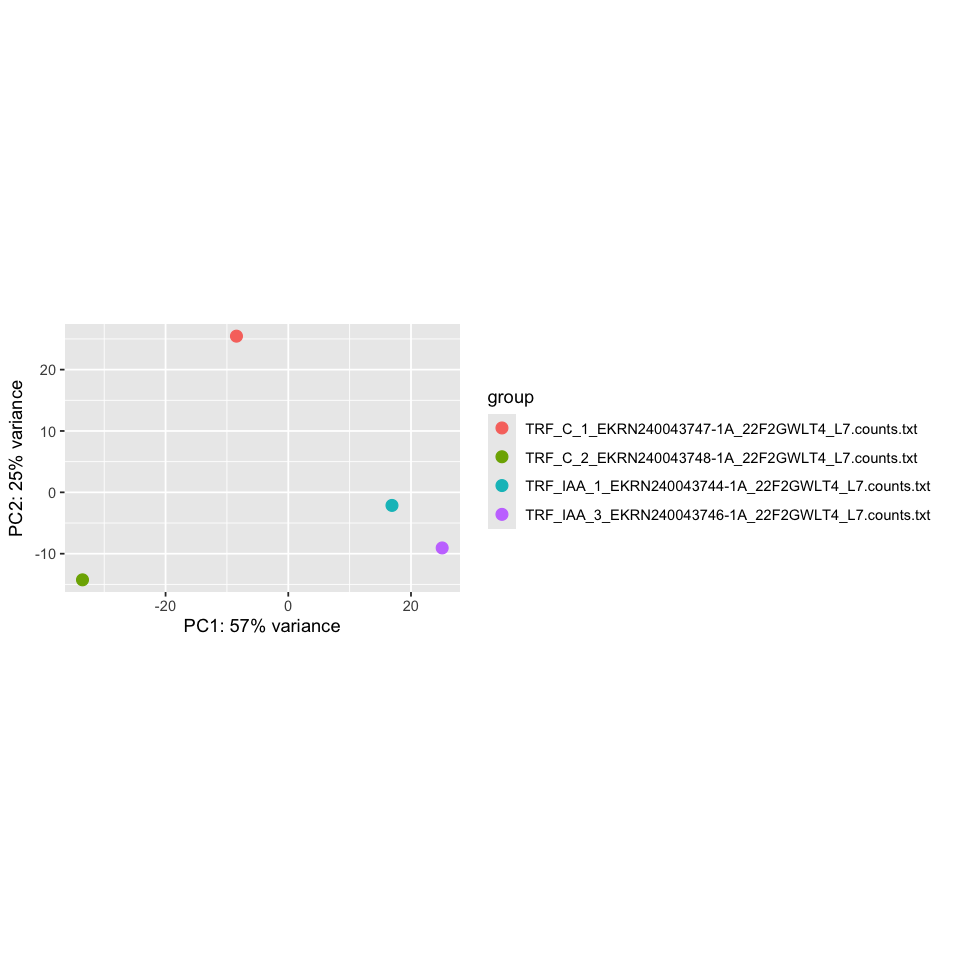

using ntop=1000 top features by variance



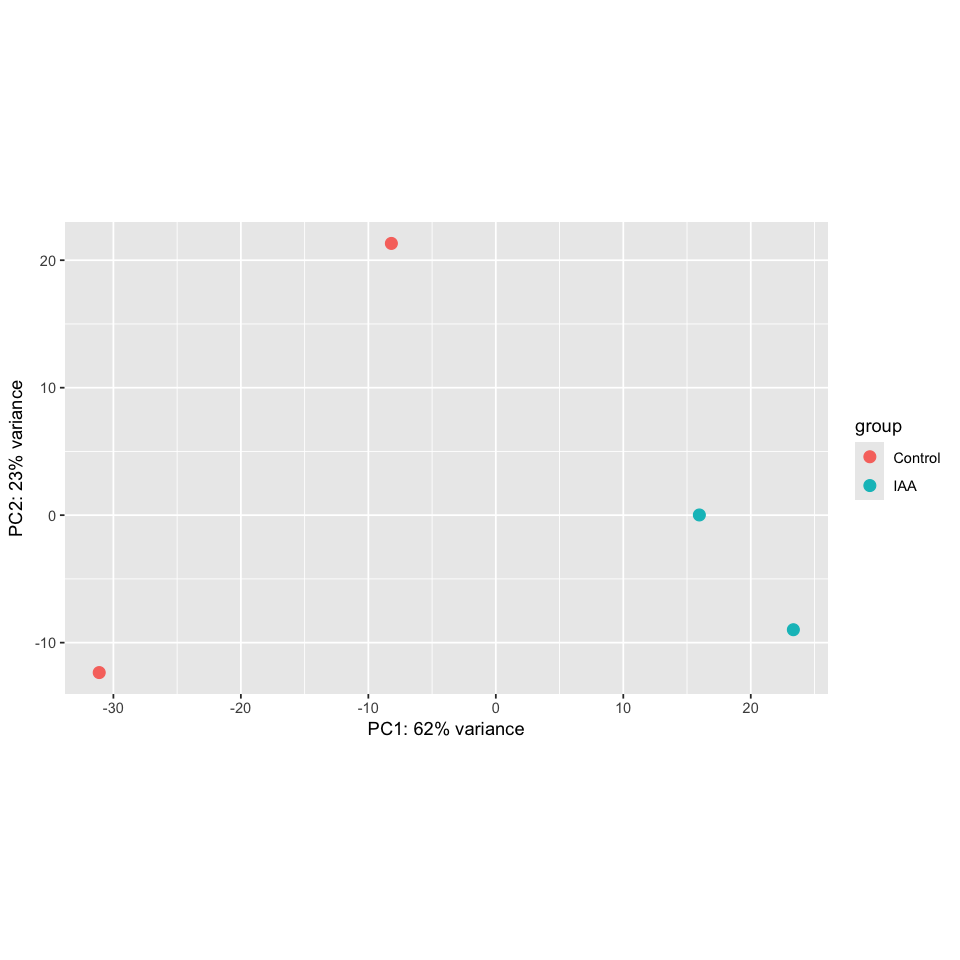

using ntop=100 top features by variance



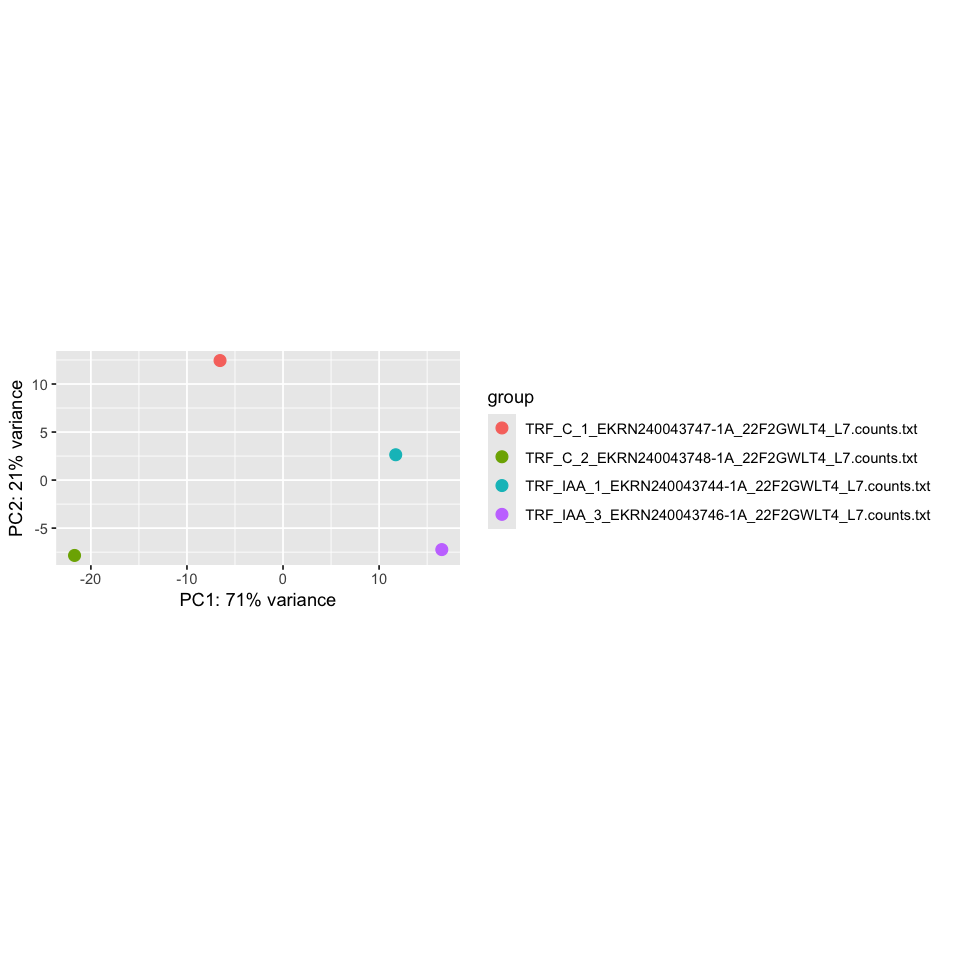

using ntop=10 top features by variance



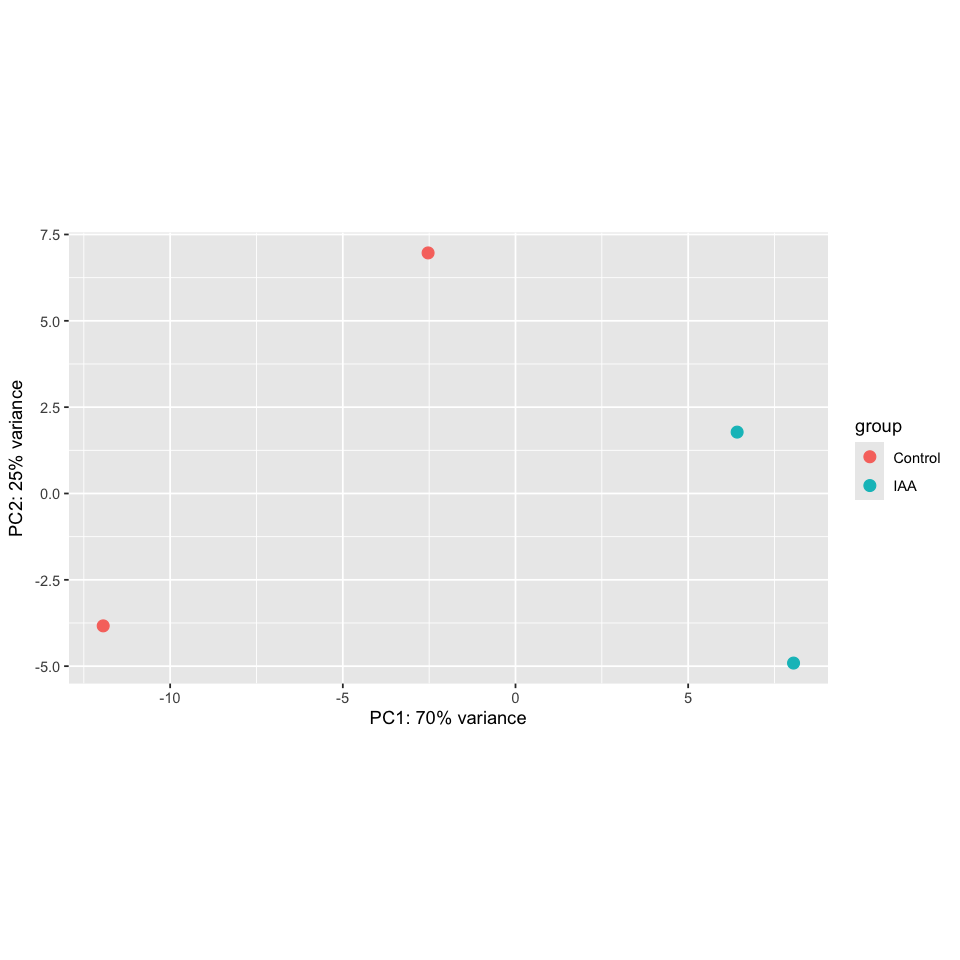

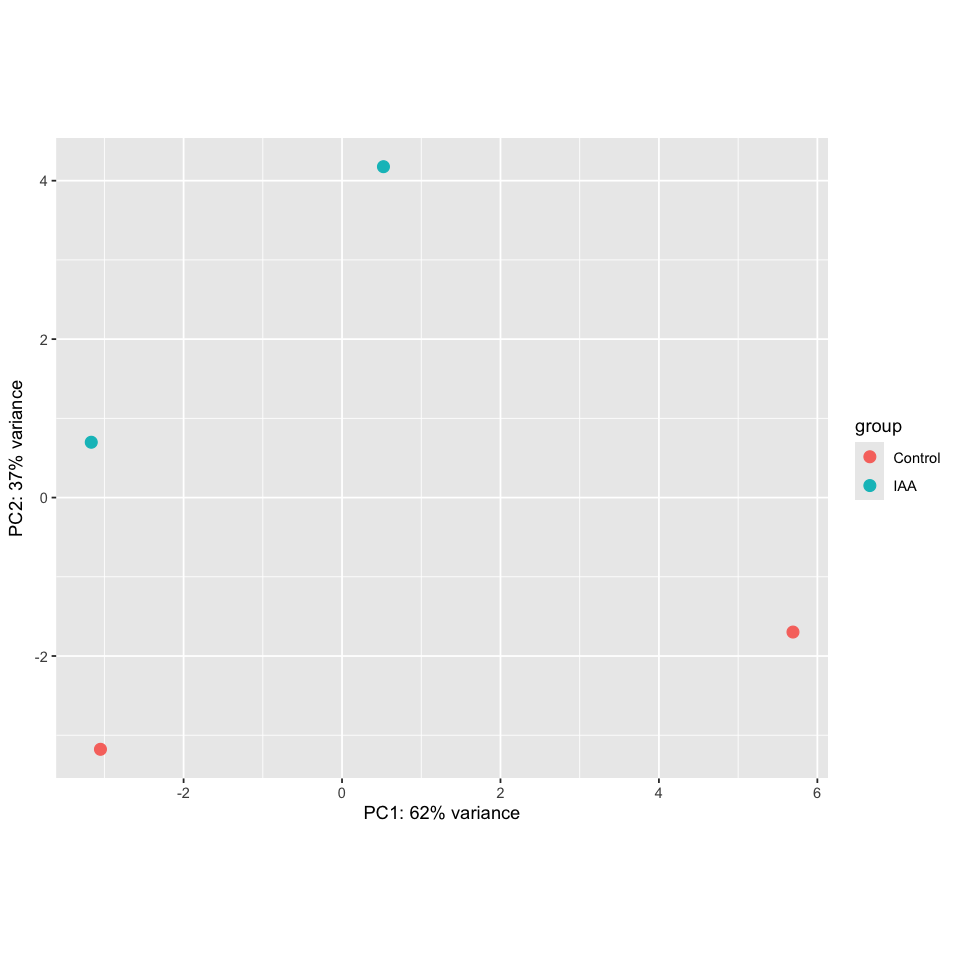

In [144]:
#filtering
dds <- dds[ rowSums(counts(dds, normalized=TRUE) >= 5) > 2, ] #only consider detected genes, >= 5 RPM in more than 2 samples


In [150]:
#filtering
dds <- dds[ rowSums(counts(dds, normalized=TRUE) >= 5) > 2, ] #only consider detected genes, >= 5 RPM in more than 2 replicates


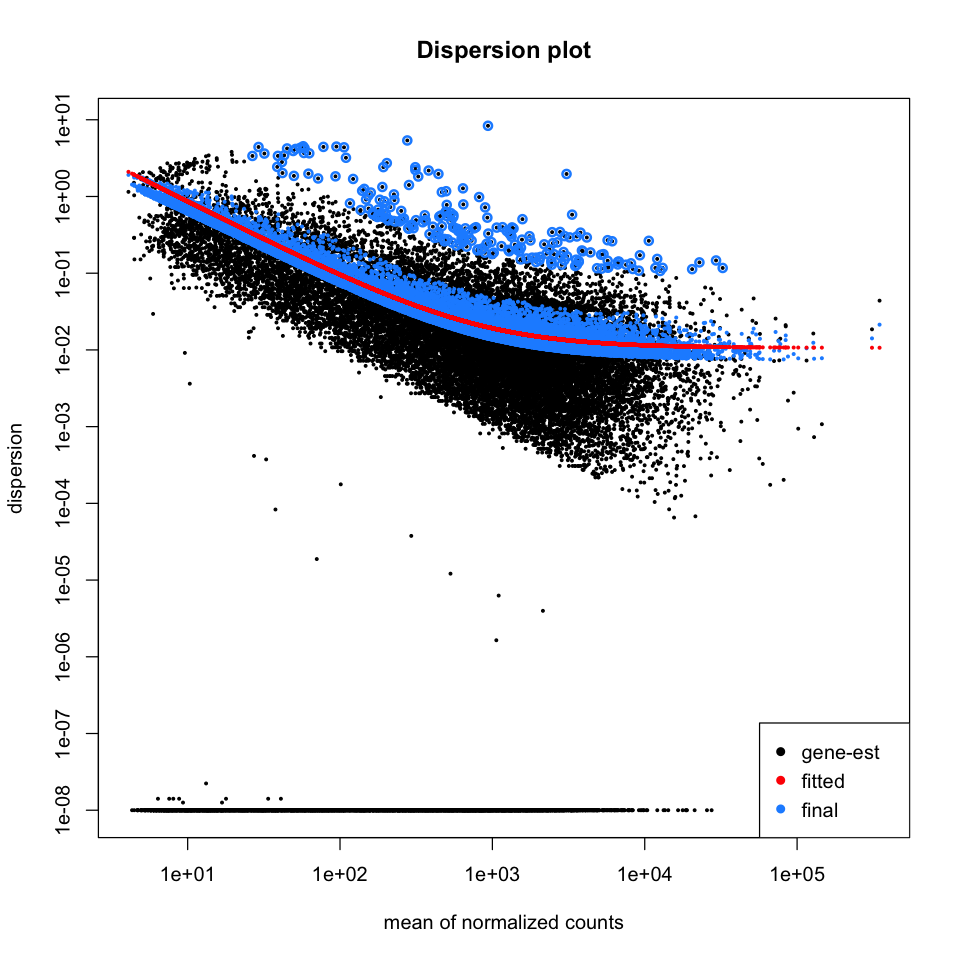

In [151]:
plotDispEsts(dds, main="Dispersion plot")


out of 25113 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 317, 1.3%
LFC < 0 (down)     : 852, 3.4%
outliers [1]       : 0, 0%
low counts [2]     : 1948, 7.8%
(mean count < 19)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MLE): Treatment IAA vs Control 
Wald test p-value: Treatment IAA vs Control 
DataFrame with 25113 rows and 6 columns
                  baseMean log2FoldChange     lfcSE       stat    pvalue
                 <numeric>      <numeric> <numeric>  <numeric> <numeric>
Zm00001eb000010  936.20620     -0.0188931  0.179242  -0.105406  0.916054
Zm00001eb000020 8807.86526      0.2343074  0.164617   1.423349  0.154635
Zm00001eb000060  874.19058     -0.1579935  0.235687  -0.670353  0.502633
Zm00001eb000070    8.06953     -0.6971012  1.387695  -0.502345  0.615425
Zm00001eb000080 1527.49178     -0.1987521  0.266057  -0.747029  0.455046
...                    ...            ...       ...        ...       ...
Zm00001eb434530   1229.620      0.0201423  0.202489  0.0994736  0.920762
Zm00001eb434540    225.966      0.1521245  0.285730  0.5324058  0.594445
Zm00001eb434550   1580.573     -0.1145484  0.182998 -0.6259548  0.531345
Zm00001eb434560   1566.202     -0.1366766  0.167236 -0.8172680

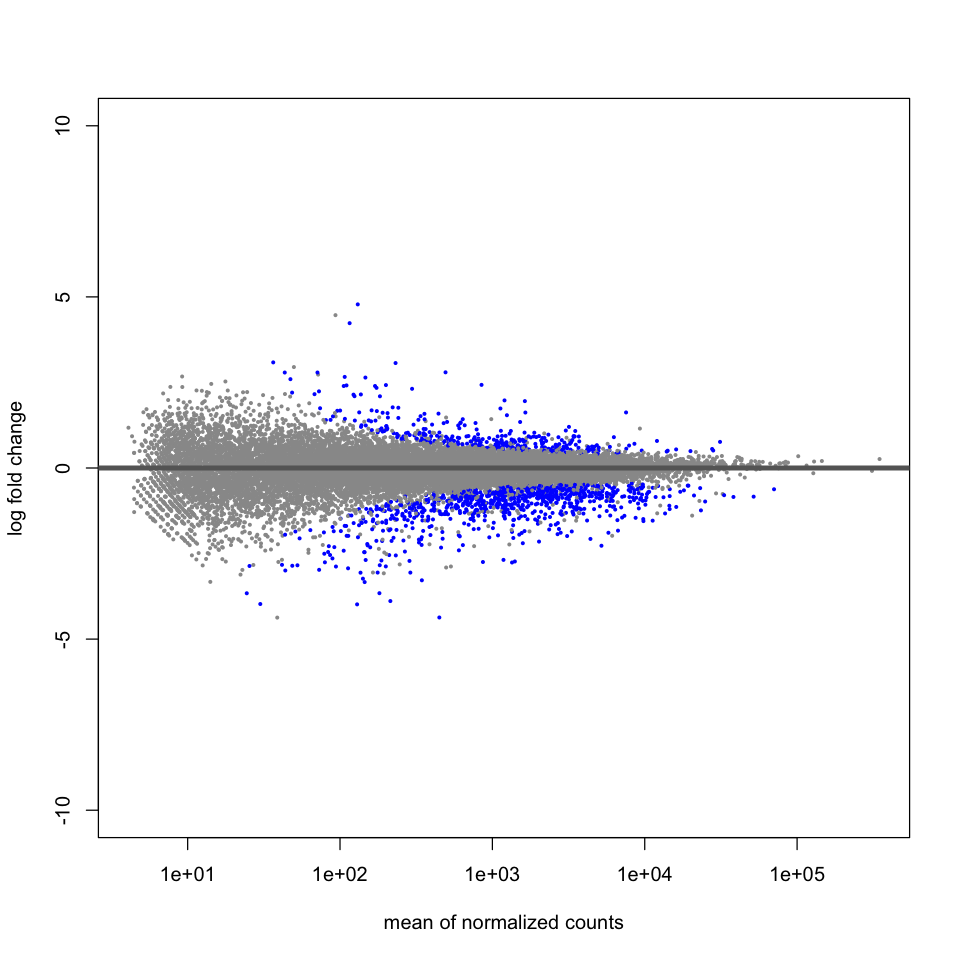

In [152]:
# Compare the mutants to N, and report genes that have padj<0.05. 
# contrast = c("condition", "treated", "nontreated")
# This contrast should report negative log2FC if expression is down in the mutant 
res <- results(dds, contrast=c("Treatment","IAA","Control"), alpha=0.05)
summary(res); #summary
plotMA(res,ylim=c(-10,10)); #smearplot
res

In [153]:
# Run GOseq on the Trf sigDE genes

# First need to generate a table with all of the genes in 1 column and then either 1 for DE or 0 for not DE in a second column
#extract gene list 
# First extract a list of all of the genes in the dataset - this is in the counts file 
dim(counts)
counts_rownames <- rownames(counts)
assayed.genes <- counts_rownames#genes [1]
dim(assayed.genes)

# Then extract a list of all of the sigDE gene names from sigDE
dim(sigDE)
sigDE_rownames <- rownames(sigDE)
de.genes <- sigDE_rownames
dim(de.genes)

# Then create a vector that has gene names asscoiated with e 1 or 0 base don it they are in both of the baove lists 
gene.vector=as.integer(assayed.genes%in%de.genes)
names(gene.vector)=assayed.genes
head(gene.vector)


[1] 39756     4

NULL

[1] 125   6

NULL

Zm00001eb000010 Zm00001eb000020 Zm00001eb000050 Zm00001eb000060 Zm00001eb000070 
              0               0               0               0               0 
Zm00001eb000080 
              0

In [154]:
# Need to make a gene length file - this info is in column 6 of the featureCounts file
featureCounts <- read.table(file_paths[1], sep="\t", header=T) # start by reading the first file
lengths <- cbind(featureCounts[,6]) # take the 6th column (counts)
rownames(lengths) <- featureCounts[,1] # name by gene

colnames(lengths) <- c('gene.length') # name the first column

head(lengths) # check on the data
dim(featureCounts) # before
dim(lengths) # after

#Remove the "gene:" from the start of the gene names 
 #head( sub("gene:", "", rownames(counts)) )
rownames(lengths) <- sub("gene:", "", rownames(lengths))
head(lengths)

# Format lengths to be like genes.vector
# First need to generate a table with all of the genes in 1 column and then either 1 for DE or 0 for not DE in a second column
#extract gene list 
 #get rownames 
lengths_rownames <- rownames (lengths)
head(lengths_rownames)
#convert rownames to column
gene.lengths <- cbind(rownames(lengths), data.frame(lengths, row.names=NULL))
head(gene.lengths)

head(gene.lengths)

# Convert the table to a named vector list
library(tibble)
gene.lengths.vector <- deframe(gene.lengths)
head(gene.lengths.vector)

,gene.length
Zm00001eb000010,3615
Zm00001eb000020,3318
Zm00001eb000050,1077
Zm00001eb000060,966
Zm00001eb000070,774
Zm00001eb000080,1738


[1] 39756     7

[1] 39756     1

,gene.length
Zm00001eb000010,3615
Zm00001eb000020,3318
Zm00001eb000050,1077
Zm00001eb000060,966
Zm00001eb000070,774
Zm00001eb000080,1738


[1] "Zm00001eb000010" "Zm00001eb000020" "Zm00001eb000050" "Zm00001eb000060"
[5] "Zm00001eb000070" "Zm00001eb000080"

,rownames(lengths),gene.length
,<chr>,<int>
1,Zm00001eb000010,3615
2,Zm00001eb000020,3318
3,Zm00001eb000050,1077
4,Zm00001eb000060,966
5,Zm00001eb000070,774
6,Zm00001eb000080,1738


,rownames(lengths),gene.length
,<chr>,<int>
1,Zm00001eb000010,3615
2,Zm00001eb000020,3318
3,Zm00001eb000050,1077
4,Zm00001eb000060,966
5,Zm00001eb000070,774
6,Zm00001eb000080,1738


Zm00001eb000010 Zm00001eb000020 Zm00001eb000050 Zm00001eb000060 Zm00001eb000070 
           3615            3318            1077             966             774 
Zm00001eb000080 
           1738

,DEgenes,bias.data,pwf
,<int>,<int>,<dbl>
Zm00001eb000010,0,3615,0.003137263
Zm00001eb000020,0,3318,0.003318593
Zm00001eb000050,0,1077,0.004379449
Zm00001eb000060,0,966,0.004379456
Zm00001eb000070,0,774,0.004379472
Zm00001eb000080,0,1738,0.004352743


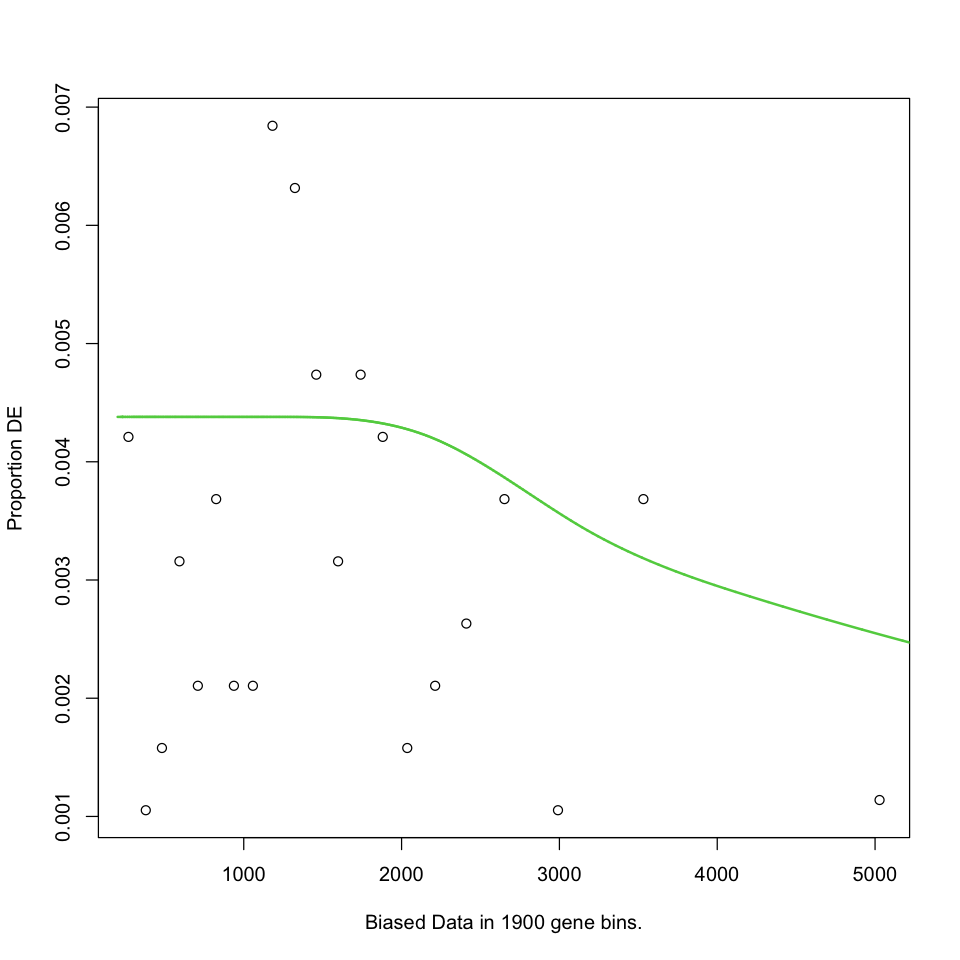

In [155]:
#To begin the analysis, goseq first needs to quantify the length bias present in the dataset under
#consideration. This is done by calculating a Probability Weighting Function or PWF which can
#be thought of as a function which gives the probability that a gene will be differentially expressed
#(DE), based on its length alone. The PWF is calculated by fitting a monotonic spline to the binary
#data series of differential expression (1=DE, 0=Not DE) as a function of gene length. The PWF is
#used to weight the chance of selecting each gene when forming a null distribution for GO category
#membership. 
# nullp(DEgenes, genome, id, bias.data=NULL,plot.fit=TRUE)
pwf=nullp(gene.vector, bias.data=gene.lengths.vector,plot.fit=TRUE)
head(pwf)

In [156]:
#Need to add a new column with adjusted pvalues for over-represented GO terms 
library(dplyr)
GO.wall.padj<-GO.wall
GO.wall.padj <- (GO.wall.padj %>% mutate (padj = (p.adjust(GO.wall.padj$over_represented_pvalue, method="BH")) ))
dim(GO.wall.padj)
head(GO.wall.padj)

[1] 9345    8

,category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj
,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>
2914,GO:0009734,1.696840e-18,1.0000000,19,360,auxin-activated signaling pathway,BP,1.585697e-14
1315,GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF,2.262125e-08
6878,GO:0046620,5.780367e-10,1.0000000,5,14,regulation of organ growth,BP,1.800584e-06
3047,GO:0009926,1.731838e-06,0.9999999,7,195,auxin polar transport,BP,4.046008e-03
3132,GO:0010046,3.812978e-06,1.0000000,3,11,response to mycotoxin,BP,7.126455e-03
8230,GO:0070566,5.199957e-06,1.0000000,3,12,adenylyltransferase activity,MF,8.098934e-03


In [157]:
# Next filter these for significantly enriched 
GO.enriched <- subset (GO.wall.padj, padj <0.05)
dim(GO.enriched)
head(GO.enriched)

[1] 13  8

,category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj
,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>
2914,GO:0009734,1.696840e-18,1.0000000,19,360,auxin-activated signaling pathway,BP,1.585697e-14
1315,GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF,2.262125e-08
6878,GO:0046620,5.780367e-10,1.0000000,5,14,regulation of organ growth,BP,1.800584e-06
3047,GO:0009926,1.731838e-06,0.9999999,7,195,auxin polar transport,BP,4.046008e-03
3132,GO:0010046,3.812978e-06,1.0000000,3,11,response to mycotoxin,BP,7.126455e-03
8230,GO:0070566,5.199957e-06,1.0000000,3,12,adenylyltransferase activity,MF,8.098934e-03


In [158]:
# Most people plot -log2 adjusted p values 
# so need to add these now 
GO_minuslogpvalues <- (GO.enriched %>% mutate (-log(padj)))
dim(GO_minuslogpvalues)
head(GO_minuslogpvalues)
# This is a table of the signifcantly enriched GO terms based on adjusted P values, with corresponding -logpadj values for plotting 

[1] 13  9

,category,over_represented_pvalue,under_represented_pvalue,numDEInCat,numInCat,term,ontology,padj,-log(padj)
,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>
2914,GO:0009734,1.696840e-18,1.0000000,19,360,auxin-activated signaling pathway,BP,1.585697e-14,31.775167
1315,GO:0005516,4.841360e-12,1.0000000,13,295,calmodulin binding,MF,2.262125e-08,17.604376
6878,GO:0046620,5.780367e-10,1.0000000,5,14,regulation of organ growth,BP,1.800584e-06,13.227399
3047,GO:0009926,1.731838e-06,0.9999999,7,195,auxin polar transport,BP,4.046008e-03,5.510025
3132,GO:0010046,3.812978e-06,1.0000000,3,11,response to mycotoxin,BP,7.126455e-03,4.943941
8230,GO:0070566,5.199957e-06,1.0000000,3,12,adenylyltransferase activity,MF,8.098934e-03,4.816023


# Let's have a quikc look at just the untreated smaples to idnetify wierd ones 


In [128]:
list.files(directory)
# Define the paths to the read files 
file_names <- list.files(path=directory, pattern = "*.txt") # create a list of all txt files in the "Tassel_stage1_counts" folder
file_paths <- list.files(path=directory, pattern = "*.txt", full.names=T) # create a list of all txt files' full locations
print(file_names)
print(file_paths)
# Building the counts table 
featureCounts <- read.table(file_paths[1], sep="\t", header=T) # start by reading the first file
#look at the first first file
dim(featureCounts)
head(featureCounts, 10)
featureCounts <- read.table(file_paths[1], sep="\t", header=T) # start by reading the first file
counts <- cbind(featureCounts[,7]) # take the 7th column (counts)
rownames(counts) <- featureCounts[,1] # name by gene

colnames(counts) <- c(file_names[1]) # name the first column

head(counts) # check on the data
dim(featureCounts) # before
dim(counts) # after

for (f in 2:length(file_paths)) { # loop over all the rest of the files
	new_featureCounts <- read.table(file_paths[f],sep="\t", header=T)
	print ("Merging file...")
	counts <- cbind(counts, new_featureCounts[,7]) # add on the new column
	colnames(counts) <- c(file_names[1:f]) # add on the new column's name
}
# View the raw counts table 
head(counts)

[1] "N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt"  
[2] "N_C_2_EKRN240043742-1A_22F2GWLT4_L7.counts.txt"  
[3] "N_C_3_EKRN240043743-1A_22F2GWLT4_L7.counts.txt"  
[4] "TRF_C_1_EKRN240043747-1A_22F2GWLT4_L7.counts.txt"
[5] "TRF_C_2_EKRN240043748-1A_22F2GWLT4_L7.counts.txt"
[6] "TRF_C_3_EKRN240043749-1A_22F2GWLT4_L7.counts.txt"

[1] "N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt"  
[2] "N_C_2_EKRN240043742-1A_22F2GWLT4_L7.counts.txt"  
[3] "N_C_3_EKRN240043743-1A_22F2GWLT4_L7.counts.txt"  
[4] "TRF_C_1_EKRN240043747-1A_22F2GWLT4_L7.counts.txt"
[5] "TRF_C_2_EKRN240043748-1A_22F2GWLT4_L7.counts.txt"
[6] "TRF_C_3_EKRN240043749-1A_22F2GWLT4_L7.counts.txt"
[1] "./featureCounts/N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt"  
[2] "./featureCounts/N_C_2_EKRN240043742-1A_22F2GWLT4_L7.counts.txt"  
[3] "./featureCounts/N_C_3_EKRN240043743-1A_22F2GWLT4_L7.counts.txt"  
[4] "./featureCounts/TRF_C_1_EKRN240043747-1A_22F2GWLT4_L7.counts.txt"
[5] "./featureCounts/TRF_C_2_EKRN240043748-1A_22F2GWLT4_L7.counts.txt"
[6] "./featureCounts/TRF_C_3_EKRN240043749-1A_22F2GWLT4_L7.counts.txt"


[1] 39756     7

,Geneid,Chr,Start,End,Strand,Length,..Desktop.TRF_AUXIN_RNAseq_July2024.aligned_reads.N_C_1_EKRN240043741.1A_22F2GWLT4_L7.bam
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
1,Zm00001eb000010,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,34617;36037;36259;36600;36822;37416;38021;38571;39701,35318;36174;36504;36713;37004;37633;38482;39618;40204,+;+;+;+;+;+;+;+;+,3615,1308
2,Zm00001eb000020,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,41214;41214;41263;41314;41742;41742;41742;41742;42257;42257;42257;42508;42508;42508;42508;42762;42762;42762;42762;43039;43039;43039;43039;43318;43318;43318;43318;43750;43750;43994;43994;43994;45593;45593;45593,41588;41588;41588;41588;41807;42375;41807;41807;42375;42375;42375;42665;42665;42665;42665;42917;42917;42917;42917;43197;43197;43197;43197;43520;43520;43520;43520;43802;43902;44303;44303;44303;46039;46050;46762,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-,3318,12534
3,Zm00001eb000050,chr1;chr1;chr1;chr1;chr1;chr1;chr1,108554;109172;109340;109498;109706;109882;113762,108564;109264;109411;109622;109790;109951;114382,-;-;-;-;-;-;-,1077,0
4,Zm00001eb000060,chr1;chr1,188559;189146,189088;189581,-;-,966,1318
5,Zm00001eb000070,chr1;chr1;chr1;chr1;chr1;chr1,190192;190301;190624;191350;197313;198535,190199;190561;190681;191442;197368;198832,-;-;-;-;-;-,774,16
6,Zm00001eb000080,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,200262;200916;201124;201433;201662;201912;202483;203022;203302,200810;201043;201211;201571;201838;202158;202592;203229;203393,-;-;-;-;-;-;-;-;-,1738,2939
7,Zm00001eb000100,chr1;chr1;chr1;chr1;chr1;chr1,206619;207090;207447;207679;208377;209221,206995;207244;207582;207819;208969;209723,-;-;-;-;-;-,1905,3
8,Zm00001eb000110,chr1;chr1,246422;246997,246545;247242,-;-,370,0
9,Zm00001eb000120,chr1,315219,315846,+,628,13


,N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt
Zm00001eb000010,1308
Zm00001eb000020,12534
Zm00001eb000050,0
Zm00001eb000060,1318
Zm00001eb000070,16
Zm00001eb000080,2939


[1] 39756     7

[1] 39756     1

[1] "Merging file..."
[1] "Merging file..."
[1] "Merging file..."
[1] "Merging file..."
[1] "Merging file..."


,N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt,N_C_2_EKRN240043742-1A_22F2GWLT4_L7.counts.txt,N_C_3_EKRN240043743-1A_22F2GWLT4_L7.counts.txt,TRF_C_1_EKRN240043747-1A_22F2GWLT4_L7.counts.txt,TRF_C_2_EKRN240043748-1A_22F2GWLT4_L7.counts.txt,TRF_C_3_EKRN240043749-1A_22F2GWLT4_L7.counts.txt
Zm00001eb000010,1308,885,1172,934,1013,1076
Zm00001eb000020,12534,10655,9657,8924,7728,10555
Zm00001eb000050,0,0,1,0,0,0
Zm00001eb000060,1318,799,791,1079,813,719
Zm00001eb000070,16,10,7,5,16,12
Zm00001eb000080,2939,1353,1454,2059,1279,1224


In [129]:
# make the sample table. NOTE: the table order must match the order that the above counts table is in
sampleTable <- read.table (text = "File,Geno,Treatment
N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt,N,Control
N_C_2_EKRN240043742-1A_22F2GWLT4_L7.counts.txt,N,Control
N_C_3_EKRN240043743-1A_22F2GWLT4_L7.counts.txt,N,Control
TRF_C_1_EKRN240043747-1A_22F2GWLT4_L7.counts.txt,Trf,Control
TRF_C_2_EKRN240043748-1A_22F2GWLT4_L7.counts.txt,Trf,Control
TRF_C_3_EKRN240043749-1A_22F2GWLT4_L7.counts.txt,Trf,Control",  sep=",", header=T)

In [130]:
#create dds object using matrix import command
# use straight forward equation for the model as we only have one variable (genotype)
ddsMatrix <- DESeqDataSetFromMatrix(countData=counts, 
                              colData=sampleTable, 
                              design=~Geno)
ddsMatrix

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


class: DESeqDataSet 
dim: 39756 6 
metadata(1): version
assays(1): counts
rownames(39756): Zm00001eb000010 Zm00001eb000020 ... Zm00001eb443020
  Zm00001eb443030
rowData names(0):
colnames(6): N_C_1_EKRN240043741-1A_22F2GWLT4_L7.counts.txt
  N_C_2_EKRN240043742-1A_22F2GWLT4_L7.counts.txt ...
  TRF_C_2_EKRN240043748-1A_22F2GWLT4_L7.counts.txt
  TRF_C_3_EKRN240043749-1A_22F2GWLT4_L7.counts.txt
colData names(3): File Geno Treatment

In [131]:
#convert into DESeq object -- will estimate dispersion
dds <- DESeq (ddsMatrix)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [132]:
#create variance stabilized table as internal norm
vsd_g <- varianceStabilizingTransformation(dds)
vsd_g_filtered <- assay(vsd_g)

using ntop=1e+05 top features by variance

using ntop=10000 top features by variance



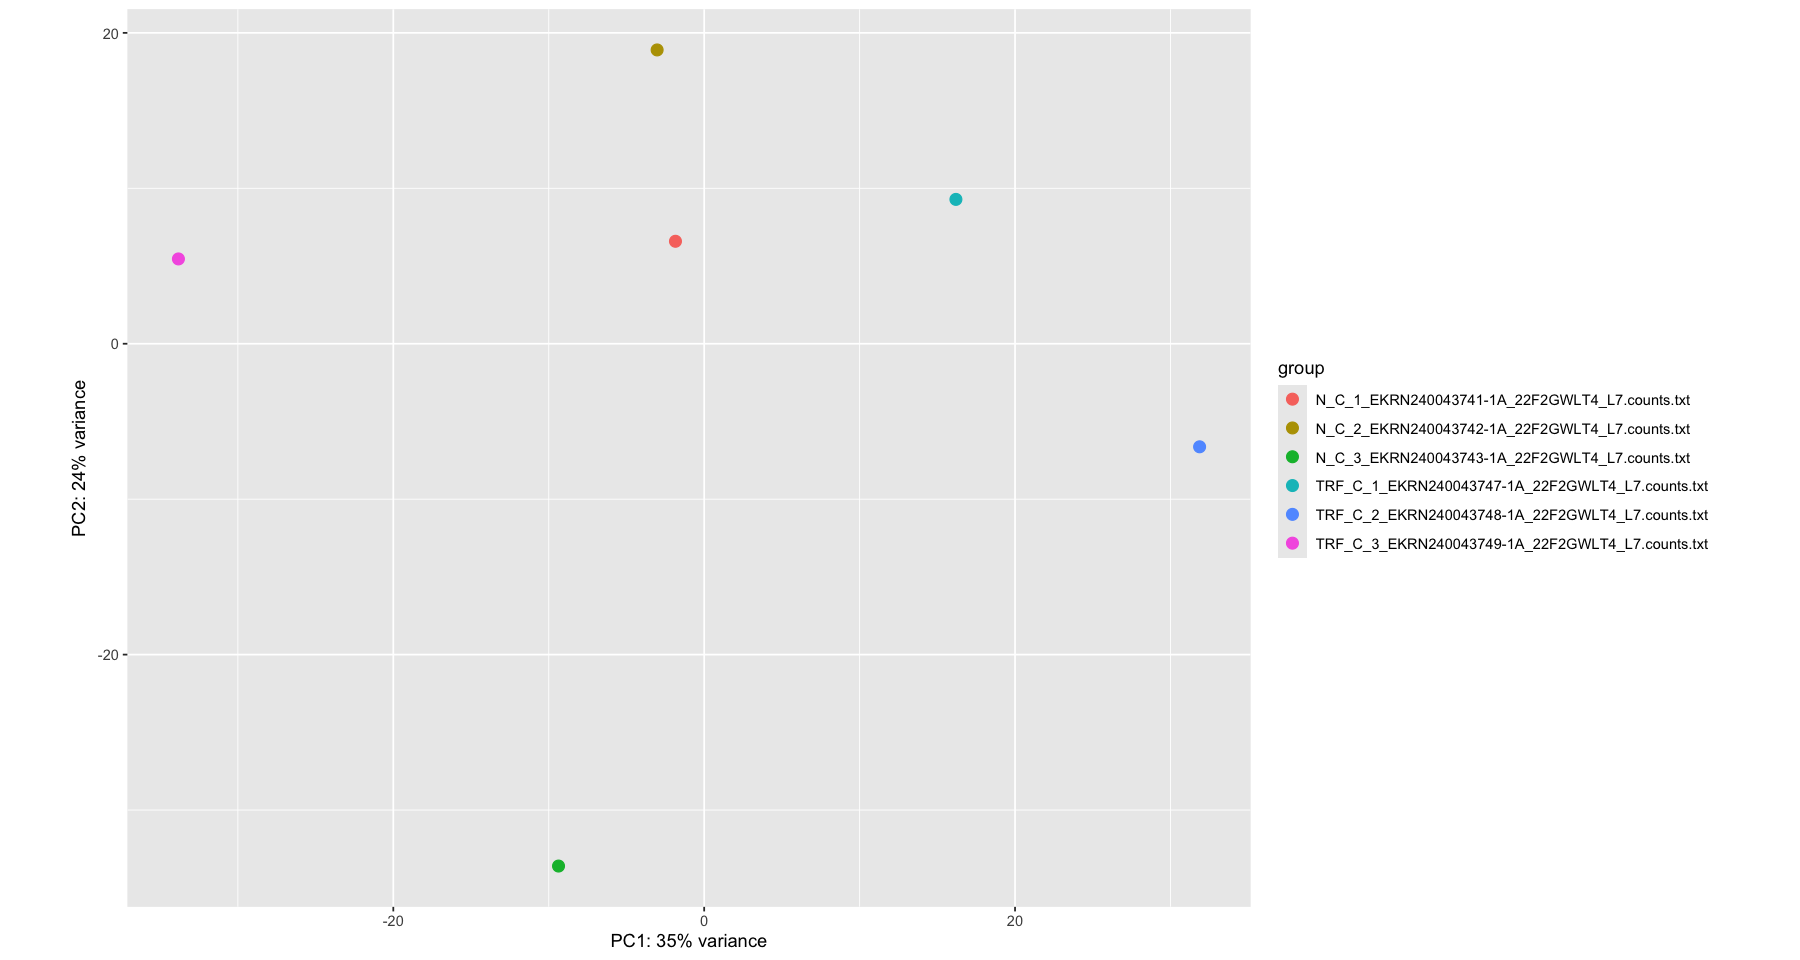

using ntop=1000 top features by variance



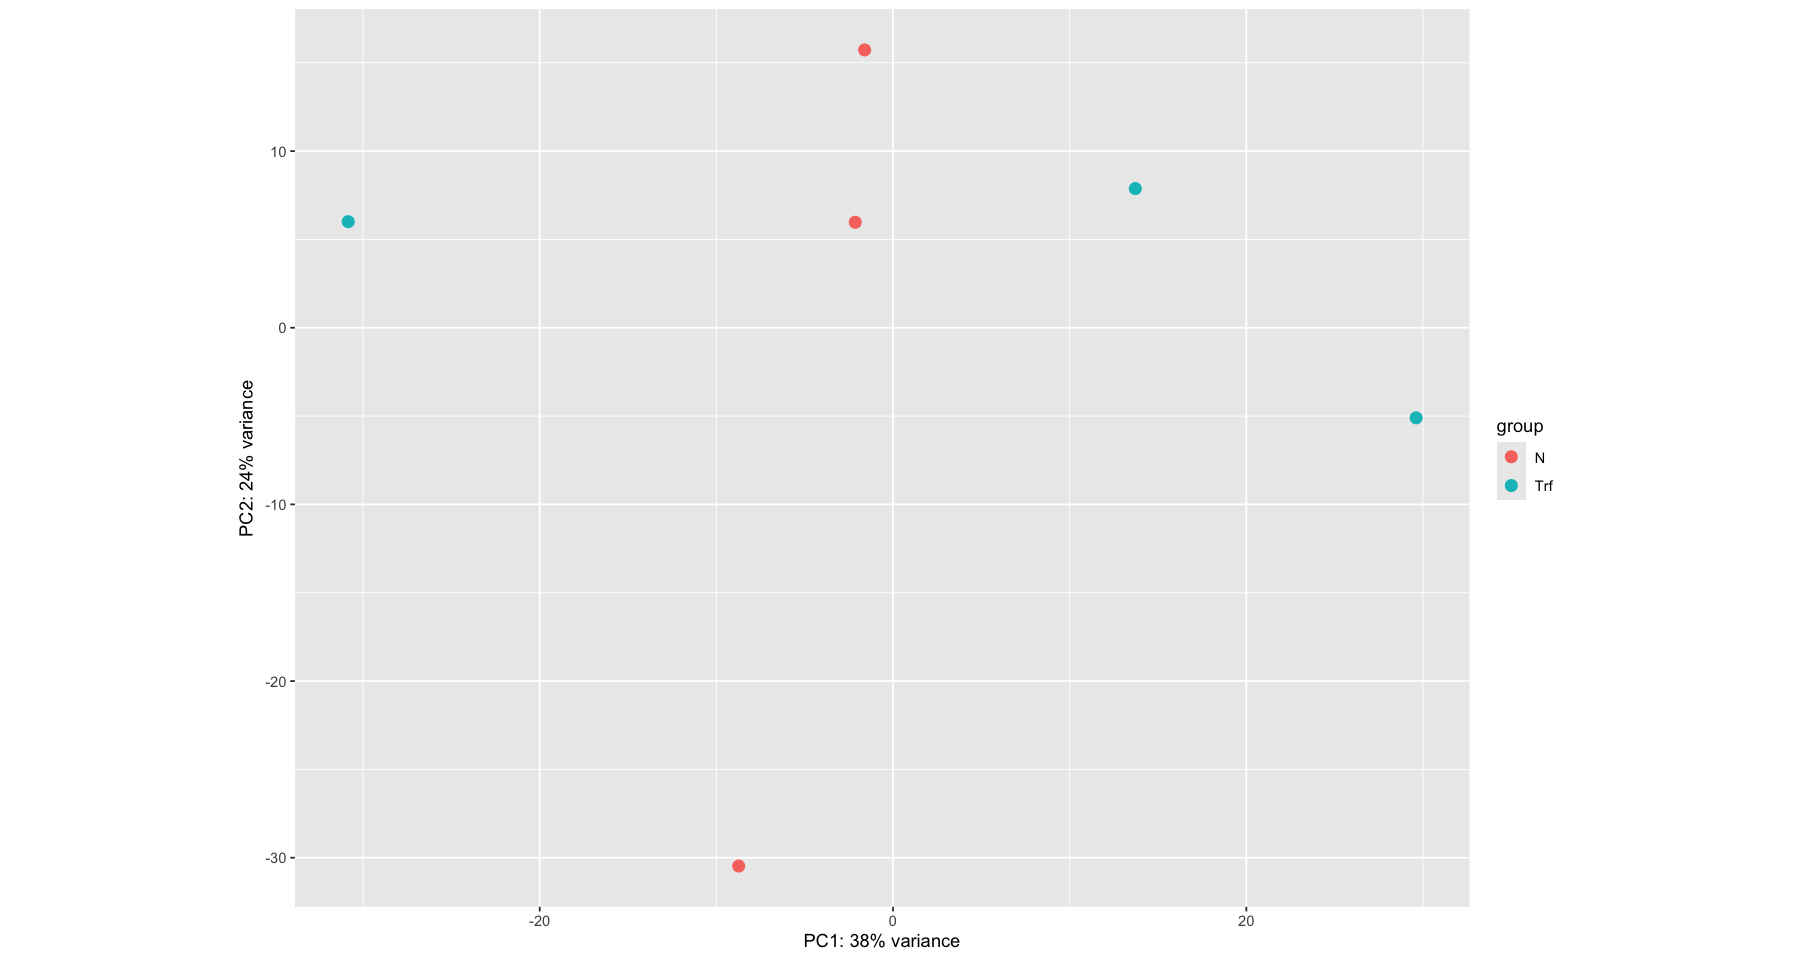

using ntop=100 top features by variance



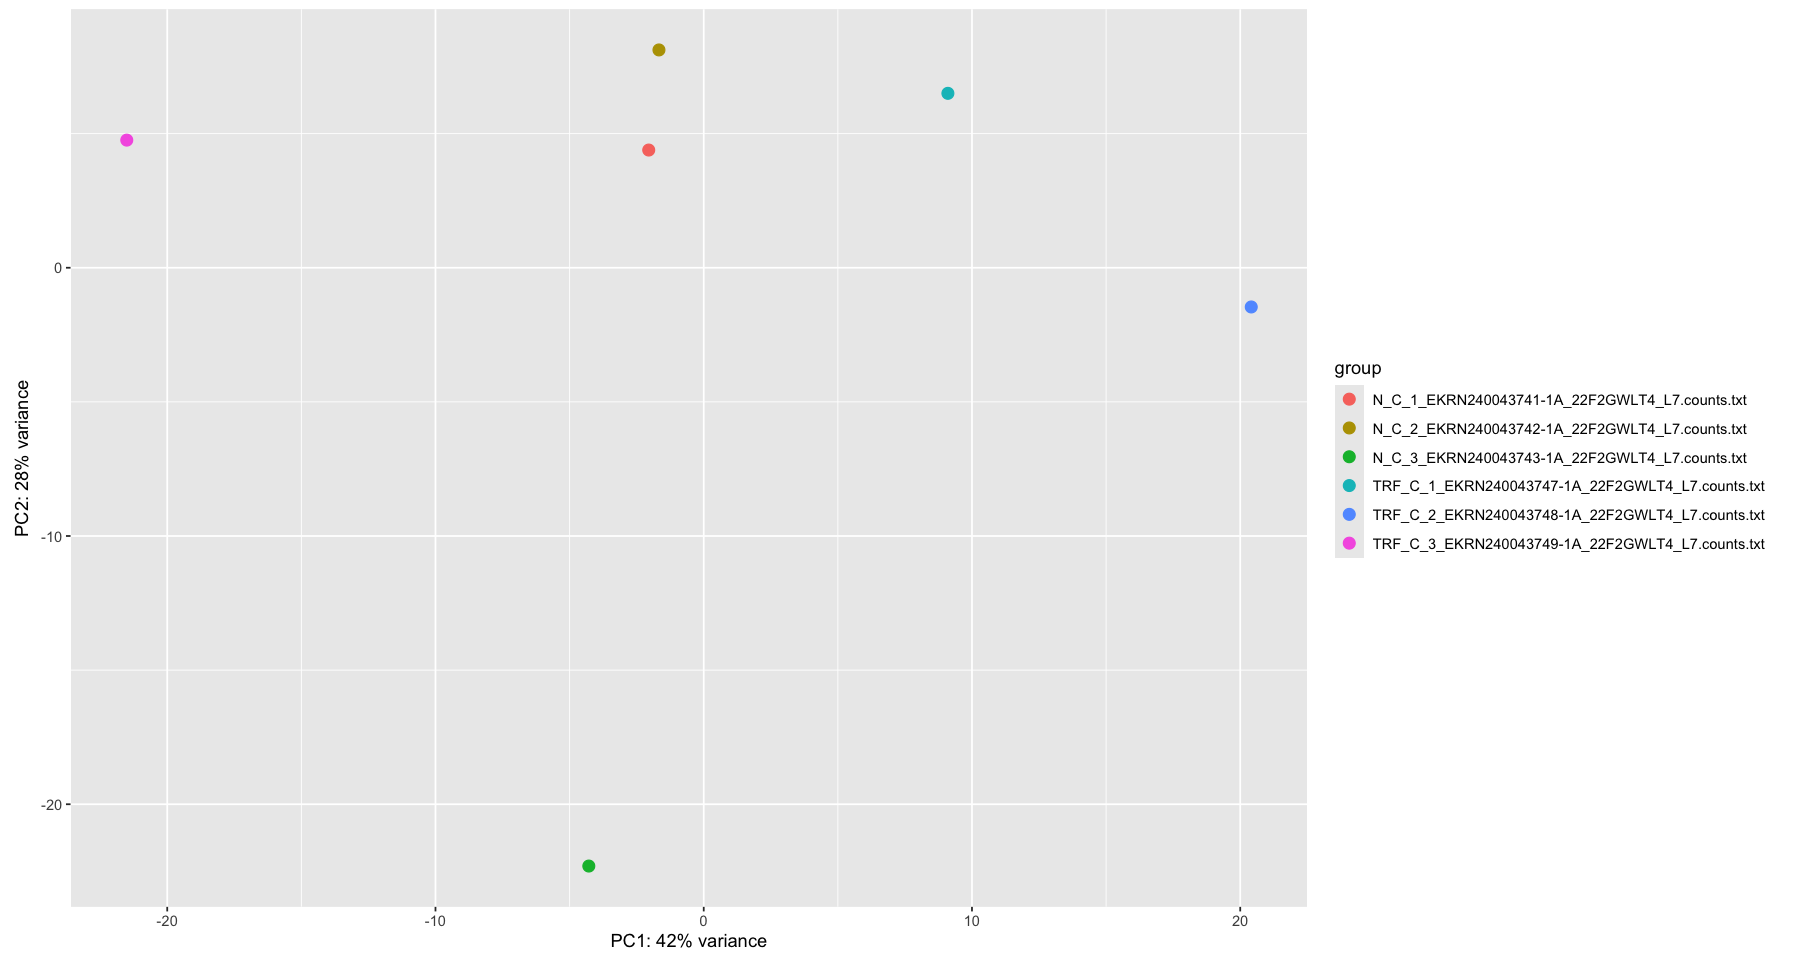

using ntop=10 top features by variance



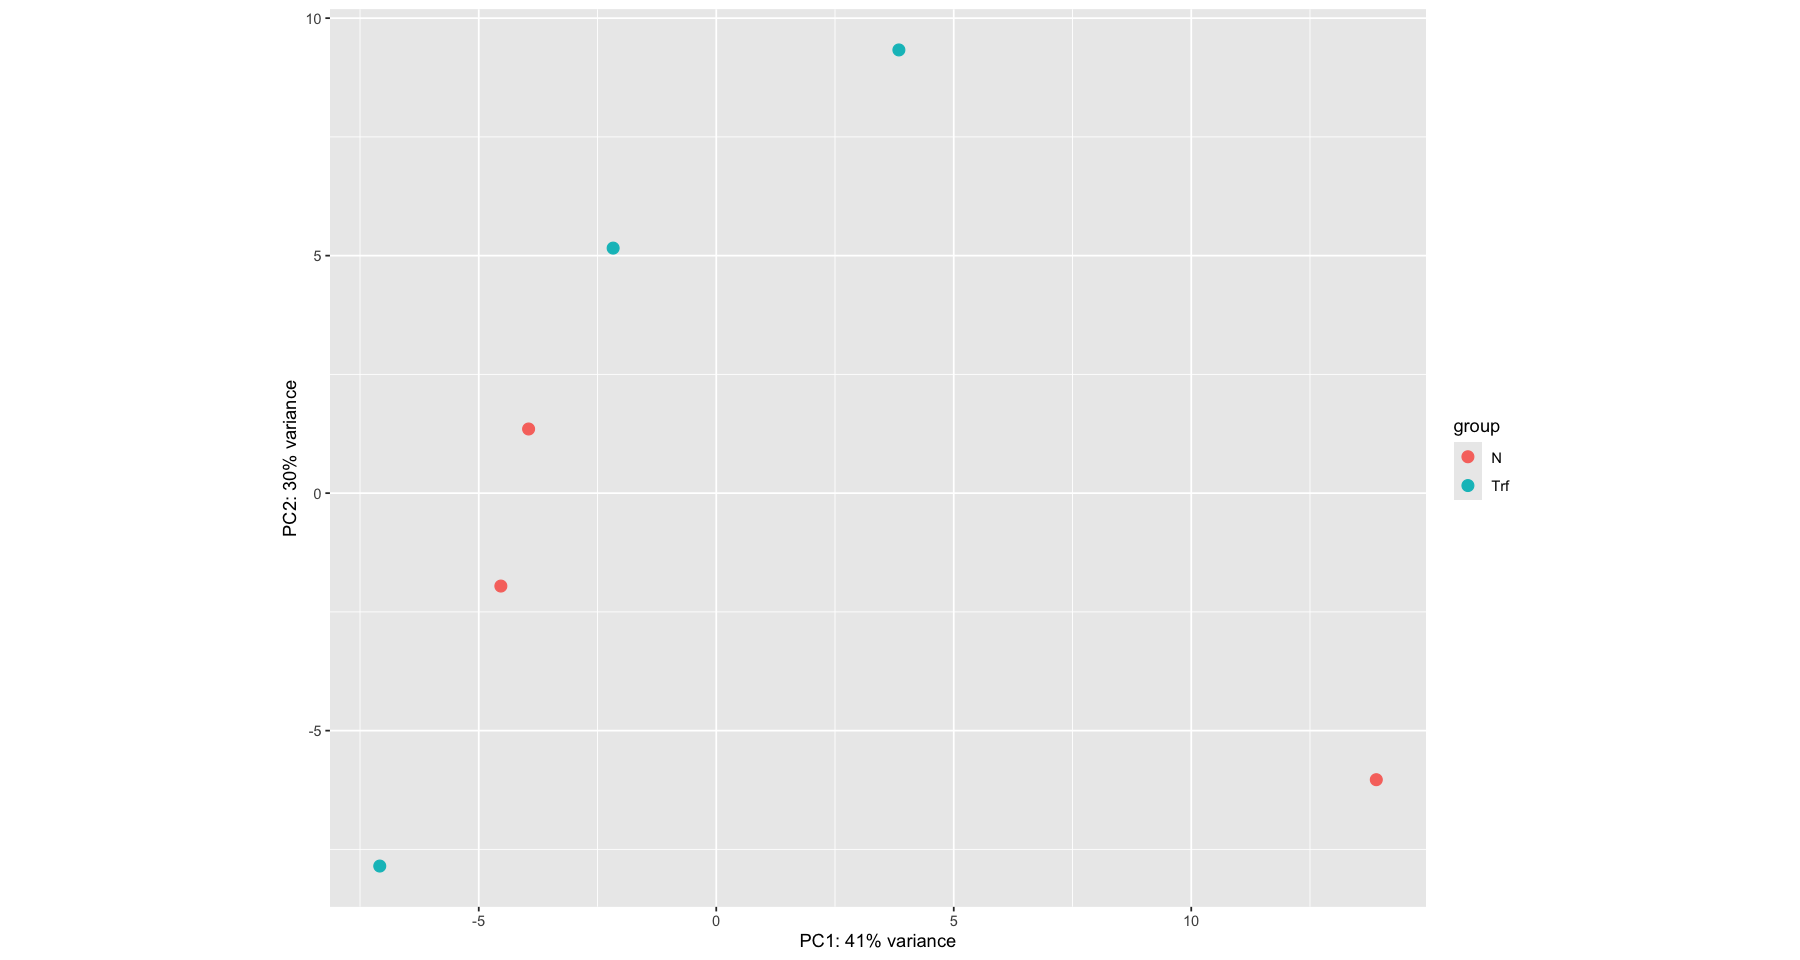

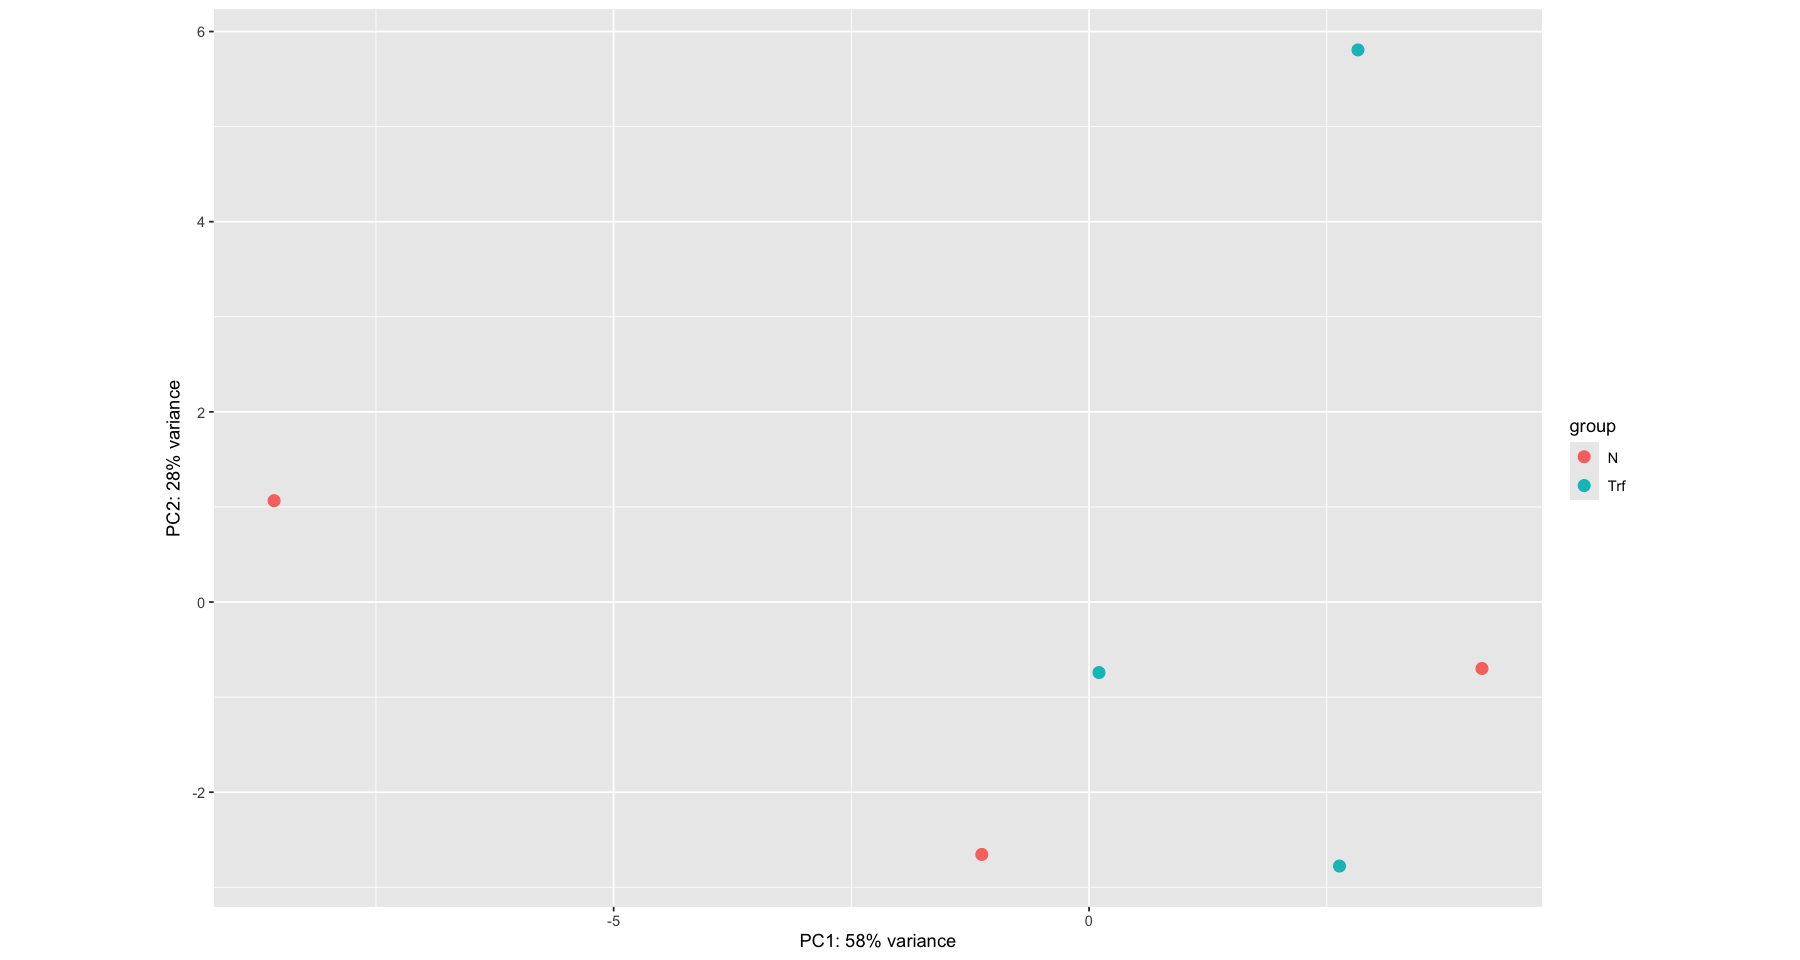

In [133]:
#check PCA plot at a few different levels, colour by genotype
plotPCA(vsd_g, intgroup=c('File'), ntop=100000)
plotPCA(vsd_g, intgroup=c('Geno'), ntop=10000)
plotPCA(vsd_g, intgroup=c('File'), ntop=1000)
plotPCA(vsd_g, intgroup=c('Geno'), ntop=100)
plotPCA(vsd_g, intgroup=c('Geno'),ntop=10)
#